# Reinforcement Learning – Imitation Learning – Assignment 1

**Course:** Reinforcement Learning  
**Assignment:** Imitation Learning — Assignment 1  


---

## Overview

This notebook implements the full pipeline for Imitation Learning on the `LunarLander-v3` Gymnasium environment:

1. **Part A** — Train an expert RL agent using Stable-Baselines3
2. **Part B1** — Collect demonstration data from the expert
3. **Part B2** — Train a neural network to imitate the expert (Behavioral Cloning)
4. **Part B3** — Evaluate the imitation model in the environment
5. **Part B4** — Analyze the effect of dataset size on performance
6. **Part B5** — Few-Shot Imitation Learning (challenge section)

---
## Setup & Installations

In [ ]:
# Install required packages
!pip install stable-baselines3[extra] gymnasium[box2d] moviepy==1.0.3 torch matplotlib numpy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 10.0 MB/s eta 0:00:00


In [ ]:
# Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from moviepy.editor import ImageSequenceClip
from IPython.display import Video, display
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import os
import pickle
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

print("All packages imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintaine

All packages imported successfully.
PyTorch version: 2.10.0+cu128
Gymnasium version: 1.2.3


---
## Part A — Training an Expert RL Agent

### A.1 — Environment & Library Setup

We use **Stable-Baselines3 (SB3)** with the **PPO** (Proximal Policy Optimization) algorithm to train an expert agent on the `LunarLander-v3` environment.

**Why PPO?**  
PPO is a robust, sample-efficient on-policy algorithm that works well on continuous and discrete action spaces. It is well-suited for LunarLander, which has 4 discrete actions: do nothing, fire left engine, fire main engine, fire right engine.

**Expert performance criterion:**   `TODO: edit, add more than whts written in the instructions, and add all the stats from the evaluation part`

We define a *good expert* as an agent achieving an **average reward ≥ 200** over 10 evaluation episodes. This aligns with the environment's standard success threshold.

In [ ]:
# Create and wrap the environment
env = gym.make("LunarLander-v3")
env = Monitor(env)

eval_env = gym.make("LunarLander-v3")
eval_env = Monitor(eval_env)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


### A.2 — Training the Expert Agent

In [ ]:
# Evaluation callback to track training progress
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./models/expert/",
    log_path="./logs/expert/",
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
    verbose=1
)

In [ ]:
# Define the PPO agent
expert_model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    policy_kwargs= dict(net_arch=[256, 256]),
    gamma=0.99,
    verbose=1,
    seed=SEED
)

Using cuda device
Wrapping the env in a DummyVecEnv.


  warnings.warn(



In [ ]:
# Train the expert
TOTAL_TIMESTEPS = 300_000
expert_model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)

print("Training complete.")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 88       |
|    ep_rew_mean     | -196     |
| time/              |          |
|    fps             | 240      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 88.8        |
|    ep_rew_mean          | -163        |
| time/                   |             |
|    fps                  | 231         |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007899794 |
|    clip_fraction        | 0.0516      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.000114   |
|    learning_rate        | 0.

### A.3 — Training Progress Plot

In [ ]:
# Load evaluation log
eval_log = np.load("./logs/expert/evaluations.npz")
timesteps = eval_log["timesteps"]
mean_rewards = eval_log["results"].mean(axis=1)
std_rewards = eval_log["results"].std(axis=1)

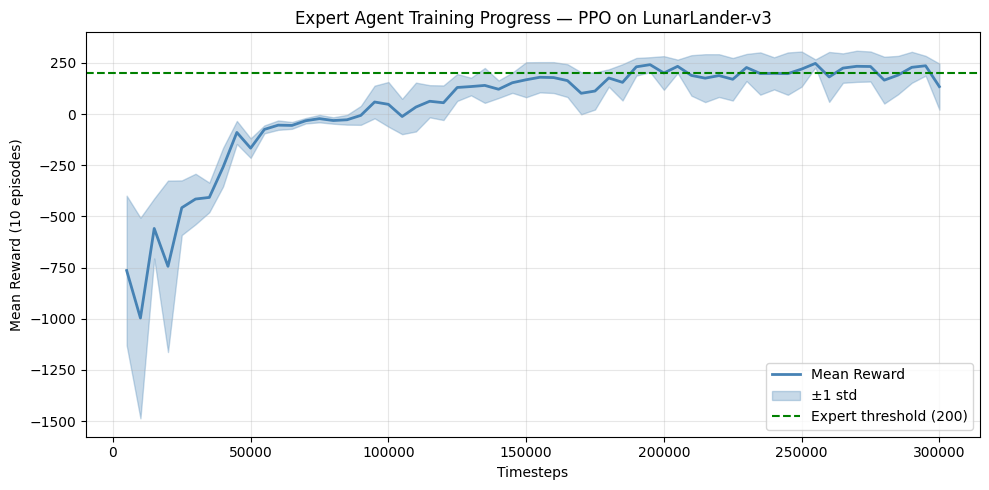

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(timesteps, mean_rewards, label="Mean Reward", color="steelblue", linewidth=2)
plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards,
                 alpha=0.3, color="steelblue", label="±1 std")
plt.axhline(y=200, color="green", linestyle="--", linewidth=1.5, label="Expert threshold (200)")
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward (10 episodes)")
plt.title("Expert Agent Training Progress — PPO on LunarLander-v3")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("expert_training_curve.png", dpi=150)
plt.show()

### A.4 — Evaluation

#### Expert Evaluation Toolkit

The cells below define helper functions for rigorously evaluating whether the trained agent qualifies as a *good expert*. Each function covers a different dimension of performance



```
TODO: add explanation to each toolkit function
```



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from scipy import stats

# ─────────────────────────────────────────────────────────────────────────────
# 1. FULL EPISODE ROLLOUT
#    Runs n_episodes and returns per-episode rewards, lengths, and the
#    step-by-step cumulative reward for every episode.
# ─────────────────────────────────────────────────────────────────────────────
def run_episodes(model, env_name='LunarLander-v3', n_episodes=100,
                 deterministic=True, seed=42):
    """
    Roll out the model for n_episodes and record:
      - total reward per episode
      - episode length (steps)
      - cumulative reward trace per episode (for intra-episode plots)

    Returns
    -------
    rewards  : np.ndarray shape (n_episodes,)
    lengths  : np.ndarray shape (n_episodes,)
    traces   : list of np.ndarray, each shape (episode_length,)
    """
    env = gym.make(env_name)
    rewards, lengths, traces = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_reward, ep_steps, cumulative = False, 0.0, 0, []

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            ep_steps  += 1
            cumulative.append(ep_reward)

        rewards.append(ep_reward)
        lengths.append(ep_steps)
        traces.append(np.array(cumulative))

    env.close()
    return np.array(rewards), np.array(lengths), traces


# ─────────────────────────────────────────────────────────────────────────────
# 2. REWARD DISTRIBUTION HISTOGRAM
#    Shows spread and consistency, not just mean.
# ─────────────────────────────────────────────────────────────────────────────
def plot_reward_distribution(rewards, threshold=200, label='Expert'):
    """
    Histogram of per-episode rewards with:
      - mean and median lines
      - expert threshold line
      - success rate annotation
    """
    success_rate = (rewards >= threshold).mean()
    ci_low, ci_high = stats.t.interval(
        0.95, df=len(rewards)-1,
        loc=rewards.mean(), scale=stats.sem(rewards)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(rewards, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(rewards.mean(),  color='navy',   lw=2,   linestyle='-',  label=f'Mean: {rewards.mean():.1f}')
    ax.axvline(np.median(rewards), color='royalblue', lw=1.5, linestyle='--', label=f'Median: {np.median(rewards):.1f}')
    ax.axvline(threshold,        color='green',  lw=1.5, linestyle=':',  label=f'Expert threshold ({threshold})')
    ax.axvspan(ci_low, ci_high,  color='steelblue', alpha=0.15, label=f'95% CI [{ci_low:.0f}, {ci_high:.0f}]')

    ax.set_xlabel('Episode Reward')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Reward Distribution ({len(rewards)} episodes)')
    ax.legend(fontsize=9)
    ax.text(0.02, 0.95, f'Success rate: {success_rate:.1%}',
            transform=ax.transAxes, va='top', fontsize=10,
            color='green' if success_rate >= 0.8 else 'red')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{label.lower()}_reward_dist.png', dpi=150)
    plt.show()
    return {'mean': rewards.mean(), 'std': rewards.std(),
            'median': np.median(rewards), 'ci': (ci_low, ci_high),
            'success_rate': success_rate}


# ─────────────────────────────────────────────────────────────────────────────
# 3. EPISODE LENGTH DISTRIBUTION
#    A good expert lands efficiently; a struggling agent times out often.
# ─────────────────────────────────────────────────────────────────────────────
def plot_episode_lengths(lengths, label='Expert'):
    """
    Histogram of episode lengths (steps until done).
    Shorter episodes generally mean faster, more decisive control.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=30, color='coral', alpha=0.75, edgecolor='white')
    ax.axvline(lengths.mean(), color='darkred', lw=2,
               label=f'Mean length: {lengths.mean():.1f} steps')
    ax.set_xlabel('Episode Length (steps)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Episode Length Distribution')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{label.lower()}_lengths.png', dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4. INTRA-EPISODE CUMULATIVE REWARD
#    Shows WHEN during an episode the agent earns/loses points.
#    Early crashes look very different from controlled slow landings.
# ─────────────────────────────────────────────────────────────────────────────
def plot_cumulative_reward_traces(traces, n_show=30, label='Expert'):
    """
    Plots step-by-step cumulative reward for each episode (light lines)
    plus the mean trajectory (bold line). Reveals whether the agent
    earns reward steadily or relies on a single final bonus.

    Parameters
    ----------
    traces : list of np.ndarray (from run_episodes)
    n_show : max number of individual episode traces to display
    """
    max_len = max(len(t) for t in traces)
    padded  = np.array([np.pad(t, (0, max_len - len(t)), constant_values=t[-1])
                        for t in traces])
    mean_trace = padded.mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))
    for trace in traces[:n_show]:
        ax.plot(trace, color='steelblue', alpha=0.15, linewidth=0.8)
    ax.plot(mean_trace, color='navy', linewidth=2.5, label='Mean trajectory')
    ax.axhline(y=0,   color='gray',  linestyle='--', lw=1, alpha=0.5)
    ax.axhline(y=200, color='green', linestyle=':',  lw=1.5, label='Threshold (200)')
    ax.set_xlabel('Step within episode')
    ax.set_ylabel('Cumulative reward')
    ax.set_title(f'{label} — Cumulative Reward Over Time (showing {n_show} episodes)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{label.lower()}_cumulative_traces.png', dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 5. MULTI-SEED STABILITY CHECK
#    Confirms performance is not specific to one random seed.
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_across_seeds(model, seeds=(0, 1, 2, 3, 4),
                           n_episodes_per_seed=20,
                           env_name='LunarLander-v3',
                           threshold=200, label='Expert'):
    """
    Evaluates the model independently for each seed and plots
    per-seed mean ± std. A robust expert should score consistently
    across different random initializations.
    """
    seed_means, seed_stds = [], []

    for seed in seeds:
        rewards, _, _ = run_episodes(model, env_name=env_name,
                                      n_episodes=n_episodes_per_seed, seed=seed)
        seed_means.append(rewards.mean())
        seed_stds.append(rewards.std())
        print(f'  Seed {seed}: {rewards.mean():.1f} ± {rewards.std():.1f} '
              f'| success: {(rewards >= threshold).mean():.0%}')

    fig, ax = plt.subplots(figsize=(8, 4))
    xs = list(range(len(seeds)))
    ax.bar(xs, seed_means, yerr=seed_stds, capsize=6,
           color='steelblue', alpha=0.8, width=0.5)
    ax.axhline(threshold, color='green', linestyle='--', lw=1.5,
               label=f'Expert threshold ({threshold})')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'Seed {s}' for s in seeds])
    ax.set_ylabel('Mean Reward')
    ax.set_title(f'{label} — Performance Across Seeds')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{label.lower()}_seed_stability.png', dpi=150)
    plt.show()
    return seed_means, seed_stds


# ─────────────────────────────────────────────────────────────────────────────
# 6. TRAINING CONVERGENCE CHECK
#    Checks whether recent evaluation checkpoints have plateaued,
#    confirming the expert has finished learning.
# ─────────────────────────────────────────────────────────────────────────────
def plot_convergence_check(log_path='./logs/expert/evaluations.npz',
                            last_n=10, threshold=200):
    """
    Loads the SB3 EvalCallback log and zooms in on the last `last_n`
    evaluation checkpoints. Low variance here confirms convergence.
    Also plots the full curve for context.
    """
    data = np.load(log_path)
    timesteps   = data['timesteps']
    all_rewards = data['results']          # shape (n_evals, n_eval_episodes)
    means = all_rewards.mean(axis=1)
    stds  = all_rewards.std(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Full training curve
    axes[0].plot(timesteps, means, color='steelblue', lw=2, label='Mean reward')
    axes[0].fill_between(timesteps, means - stds, means + stds,
                         alpha=0.2, color='steelblue')
    axes[0].axhline(threshold, color='green', linestyle='--', lw=1.5,
                    label=f'Threshold ({threshold})')
    axes[0].set_title('Full training curve')
    axes[0].set_xlabel('Timesteps')
    axes[0].set_ylabel('Mean reward')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Convergence zoom (last N evals)
    axes[1].plot(timesteps[-last_n:], means[-last_n:],
                 color='navy', lw=2, marker='o', label='Mean reward')
    axes[1].fill_between(timesteps[-last_n:],
                         means[-last_n:] - stds[-last_n:],
                         means[-last_n:] + stds[-last_n:],
                         alpha=0.2, color='navy')
    axes[1].axhline(threshold, color='green', linestyle='--', lw=1.5,
                    label=f'Threshold ({threshold})')
    conv_std = means[-last_n:].std()
    axes[1].set_title(f'Convergence check (last {last_n} evals | σ={conv_std:.1f})')
    axes[1].set_xlabel('Timesteps')
    axes[1].set_ylabel('Mean reward')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Training Convergence Analysis', fontsize=13)
    plt.tight_layout()
    plt.savefig('convergence_check.png', dpi=150)
    plt.show()
    print(f'Last {last_n} evals → mean: {means[-last_n:].mean():.1f}, '
          f'std across checkpoints: {conv_std:.1f}')


# ─────────────────────────────────────────────────────────────────────────────
# 7. RANDOM POLICY BASELINE COMPARISON
#    Quantifies how far above chance the expert actually is.
# ─────────────────────────────────────────────────────────────────────────────
def compare_with_random_baseline(model, env_name='LunarLander-v3',
                                  n_episodes=100, seed=42, threshold=200):
    """
    Runs both the trained model and a random policy for n_episodes,
    then plots a side-by-side comparison.
    """
    # Random baseline
    env = gym.make(env_name)
    rand_rewards = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_reward = False, 0.0
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        rand_rewards.append(ep_reward)
    env.close()
    rand_rewards = np.array(rand_rewards)

    # Expert
    expert_rewards, _, _ = run_episodes(model, env_name=env_name,
                                         n_episodes=n_episodes, seed=seed)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(
        min(rand_rewards.min(), expert_rewards.min()),
        max(rand_rewards.max(), expert_rewards.max()), 35
    )
    ax.hist(rand_rewards,    bins=bins, alpha=0.6, color='gray',      label='Random policy')
    ax.hist(expert_rewards,  bins=bins, alpha=0.6, color='steelblue', label='Expert (PPO)')
    ax.axvline(rand_rewards.mean(),   color='dimgray',   lw=2, linestyle='--',
               label=f'Random mean: {rand_rewards.mean():.0f}')
    ax.axvline(expert_rewards.mean(), color='navy',      lw=2, linestyle='-',
               label=f'Expert mean: {expert_rewards.mean():.0f}')
    ax.axvline(threshold,             color='green',     lw=1.5, linestyle=':',
               label=f'Expert threshold ({threshold})')
    ax.set_xlabel('Episode Reward')
    ax.set_ylabel('Count')
    ax.set_title('Expert vs Random Policy — Reward Distribution')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('expert_vs_random.png', dpi=150)
    plt.show()

    print(f'Random  → mean: {rand_rewards.mean():.1f}, '
          f'success: {(rand_rewards >= threshold).mean():.1%}')
    print(f'Expert  → mean: {expert_rewards.mean():.1f}, '
          f'success: {(expert_rewards >= threshold).mean():.1%}')


print('All expert evaluation functions defined.')

def create_video(frames, video_filename, fps):
    clip = ImageSequenceClip(frames, fps=fps)
    clip.write_videofile(video_filename, fps=fps)
    display(Video(video_filename, embed=True, width=600))

All expert evaluation functions defined.


#### Running the Evaluation

Call each function on the trained `best_expert` model. Together they answer the question: *is this agent good enough to be a demonstration source?*

In [ ]:
best_expert = PPO.load("./models/expert/best_model")
print("Best expert model loaded successfully and ready for data collection!")

Best expert model loaded successfully and ready for data collection!


In [ ]:
# Step 1 — collect raw episode data (used by most functions below)
rewards, lengths, traces = run_episodes(
    model=best_expert, n_episodes=100, seed=42
)

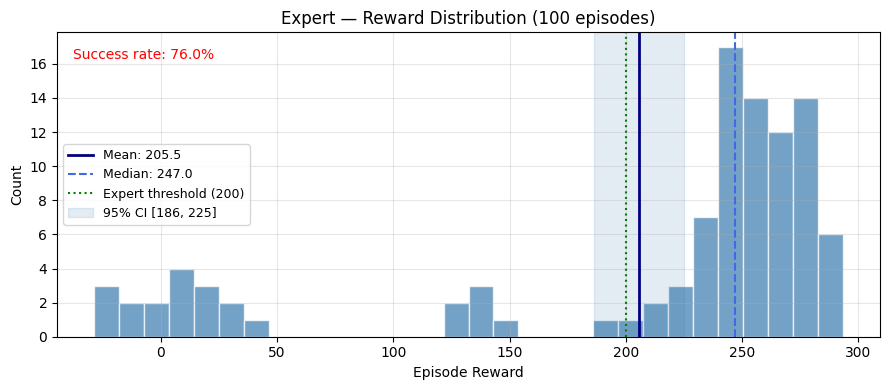

In [ ]:
# Step 2 — reward distribution with 95% CI and success rate
stats_summary = plot_reward_distribution(rewards, threshold=200)

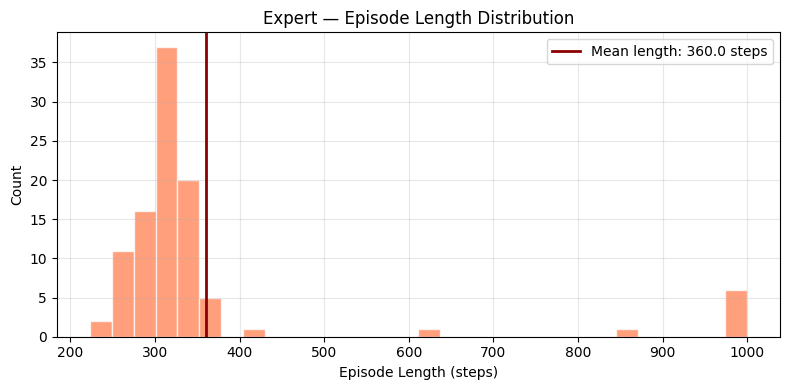

In [ ]:
# Step 3 — episode lengths
plot_episode_lengths(lengths)

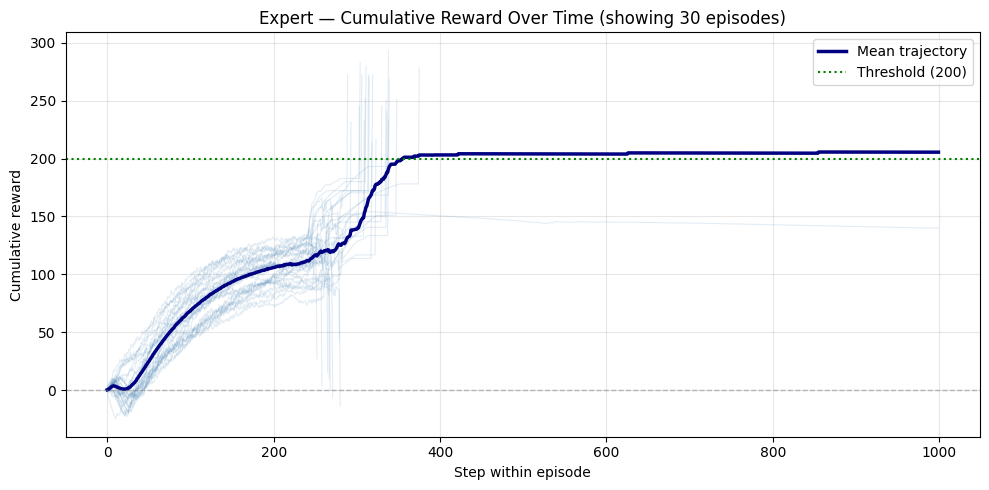

In [ ]:
# Step 4 — cumulative reward over time within each episode
plot_cumulative_reward_traces(traces, n_show=30)

  Seed 0: 228.7 ± 69.0 | success: 85%
  Seed 1: 214.1 ± 85.3 | success: 80%
  Seed 2: 214.3 ± 85.4 | success: 80%
  Seed 3: 208.0 ± 89.7 | success: 75%


  return datetime.utcnow().replace(tzinfo=utc)



  Seed 4: 204.0 ± 90.6 | success: 70%


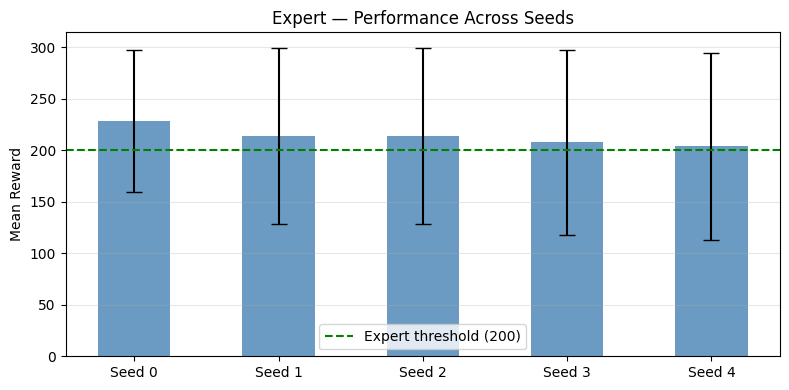

([np.float64(228.67900546789625),
  np.float64(214.09037827782518),
  np.float64(214.3308878629322),
  np.float64(207.96583035103063),
  np.float64(204.03547521546963)],
 [np.float64(69.01067642645955),
  np.float64(85.26175500630352),
  np.float64(85.37081582107731),
  np.float64(89.68050357645843),
  np.float64(90.61484957377728)])

In [ ]:
# Step 5 — stability across 5 different random seeds
evaluate_across_seeds(best_expert, seeds=(0, 1, 2, 3, 4), n_episodes_per_seed=20)

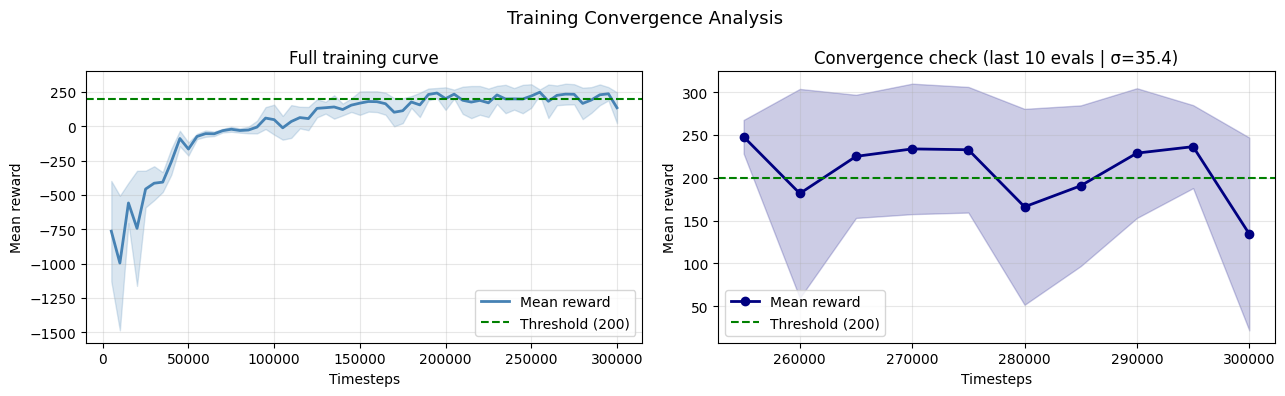

Last 10 evals → mean: 207.7, std across checkpoints: 35.4


In [ ]:
# Step 6 — convergence check (requires the EvalCallback log file)
plot_convergence_check(log_path='./logs/expert/evaluations.npz', last_n=10)

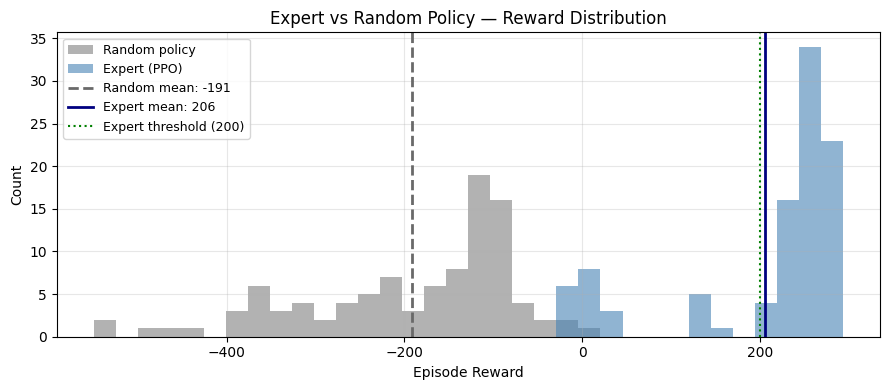

Random  → mean: -191.1, success: 0.0%
Expert  → mean: 205.5, success: 76.0%


In [ ]:
# Step 7 — compare expert against a random policy baseline
compare_with_random_baseline(best_expert, n_episodes=100)

In [ ]:
# Step 8 — show performance
env_name="LunarLander-v3"
eval_env = gym.make(env_name, render_mode="rgb_array")
frames = []
done = False
obs, info = eval_env.reset()
while not done:
    frames.append(eval_env.render())
    action, _states = best_expert.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
eval_env.close()
video_filename = "LunarLander_expert_episode.mp4"
create_video(frames, video_filename=video_filename, fps=30)

Moviepy - Building video LunarLander_expert_episode.mp4.
Moviepy - Writing video LunarLander_expert_episode.mp4



Moviepy - Done !
Moviepy - video ready LunarLander_expert_episode.mp4


---
## Part B — Imitation Learning

### B1 — Collecting Demonstration Data

We run the trained expert agent in the environment and record `(state, action)` pairs at every timestep. We build several datasets of different sizes for later analysis.

**Data collection details:**
- The expert acts **deterministically** (greedy w.r.t. its policy)
- We collect complete episodes and store all transitions
- Dataset sizes: **100, 500, 1000, 5000, 10000** samples
- We used sub-sampling

**B1. Collecting Demonstration Data**

In [ ]:
def collect_demonstrations(model, env_name, num_episodes, seed=SEED):
    """
    Run the expert model for n_episodes and collect (state, action) pairs.
    Returns arrays of states and actions.
    """
    collect_env = gym.make(env_name)
    states, actions = [], []
    episode_rewards = []

    for ep in range(num_episodes):
        obs, _ = collect_env.reset(seed=seed + ep)
        done = False
        episode_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)

            states.append(obs)
            actions.append(action)

            obs, reward, terminated, truncated, _ = collect_env.step(action)
            done = terminated or truncated
            episode_reward += reward
        episode_rewards.append(episode_reward)

    collect_env.close()

    print(f"Collected {len(states)} transitions over {num_episodes} episodes.")
    print(f"  Mean episode reward: {np.mean(episode_rewards):.2f} ± {np.std(episode_rewards):.2f}")
    return np.array(states, dtype=np.float32), np.array(actions, dtype=np.int64)

In [ ]:
# Collect a large pool of demonstrations
N_COLLECTION_EPISODES = 200
all_states, all_actions = collect_demonstrations(best_expert, "LunarLander-v3", N_COLLECTION_EPISODES)

# Save full dataset
os.makedirs("./data", exist_ok=True)
with open("./data/demonstrations_full.pkl", "wb") as f:
    pickle.dump({"states": all_states, "actions": all_actions}, f)

print(f"\nTotal samples collected: {len(all_states)}")
print(f"State shape: {all_states.shape}")
print(f"Action distribution: {np.bincount(all_actions)}")

Collected 70573 transitions over 200 episodes.
  Mean episode reward: 216.44 ± 87.49

Total samples collected: 70573
State shape: (70573, 8)
Action distribution: [29605  4657 29048  7263]


In [ ]:
# Build datasets of different sizes by subsampling
DATASET_SIZES = [100, 500, 1000, 5000, 10000]
datasets = {}

for size in DATASET_SIZES:
    if size <= len(all_states):
        idx = np.random.choice(len(all_states), size=size, replace=False)
        datasets[size] = {
            "states": all_states[idx],
            "actions": all_actions[idx]
        }
        print(f"Dataset size {size:>6}: {datasets[size]['states'].shape}")
    else:
        print(f"⚠️  Requested size {size} exceeds available data ({len(all_states)}). Skipping.")

Dataset size    100: (100, 8)
Dataset size    500: (500, 8)
Dataset size   1000: (1000, 8)
Dataset size   5000: (5000, 8)
Dataset size  10000: (10000, 8)


### B2 — Training an Imitation Model

We treat this as a standard **multi-class classification** problem:
- **Input:** 8-dimensional state observation
- **Output:** one of 4 discrete actions

**Architecture:**
- 3-layer fully connected network
- Hidden sizes: 256 → 128 → 64
- ReLU activations, batch normalization, Dropout
- Output: 4 logits → softmax for action probabilities

**Training setup:**
- Loss: Cross-Entropy
- Optimizer: Adam (lr=1e-3)
- 80/20 train/validation split
- Early stopping based on validation loss



```
TODO: add short explanation of the design choices you made. including batch size = 64
```



In [ ]:
class ImitationNet(nn.Module):
    """Behavioral Cloning network for LunarLander (discrete actions)."""

    def __init__(self, input_dim=8, hidden_dims=[256, 128, 64], output_dim=4):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.ReLU()
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)

    def predict(self, observation, state=None, episode_start=None, deterministic=False):
        """Predict a single action from a numpy state vector, matching SB3 API."""
        self.eval()
        device = next(self.parameters()).device
        with torch.no_grad():
            x = torch.FloatTensor(observation).unsqueeze(0).to(device)
            logits = self(x)
            return logits.argmax(dim=1).item(), state

print("Model utilities defined.")

Model utilities defined.


In [ ]:
def make_dataloaders(states, actions, val_split=0.2, batch_size=256):
    """Build train and validation DataLoaders from numpy arrays."""

    X_train, X_val, y_train, y_val = train_test_split(
        states, actions, test_size=val_split, shuffle=False
    )
    # Convert to Tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)

    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size)
    )


def train_imitation_model(states, actions, batch_size, n_epochs=50, lr=1e-3):
    """Train a BC model and return it along with training history."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ImitationNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader, val_loader = make_dataloaders(states, actions, batch_size=batch_size)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            train_correct += (logits.argmax(1) == y_batch).sum().item()
            train_total += len(y_batch)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
                val_total += len(y_batch)

        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = train_correct / train_total
        v_acc = val_correct / val_total

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train Loss: {t_loss:.4f} Acc: {t_acc:.3f} "
                  f"| Val Loss: {v_loss:.4f} Acc: {v_acc:.3f}")

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


print("Training utilities defined.")

Training utilities defined.


In [ ]:
def plot_learning_curves(history, size):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.title("Behavioral Cloning Training — Imitation Model", fontsize=14)

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="coral", linestyle="--")
    axes[0].set_title(f"Loss Curves — {size} samples")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy", color="steelblue")
    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="coral", linestyle="--")
    axes[1].set_title(f"Accuracy Curves — {size} samples")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"Behavioral Cloning Training — {size} Samples", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"bc_training_curves_{size}_samples.png", dpi=150)
    plt.show()

In [ ]:
# Train model on all datasets and compare
history = {}
for dataset_size in DATASET_SIZES:
    print(f"Training imitation model on {dataset_size} samples...")

    main_model, size_history = train_imitation_model(
      datasets[dataset_size]["states"],
      datasets[dataset_size]["actions"],
      batch_size=64,
      n_epochs=100,
)

    history[dataset_size] = size_history

    os.makedirs("./models/imitation", exist_ok=True)
    torch.save(main_model.state_dict(), f"./models/imitation/bc_model_{dataset_size}.pt")
    print("Model saved.")

Training imitation model on 100 samples...
  Epoch  10 | Train Loss: 1.1300 Acc: 0.588 | Val Loss: 1.1906 Acc: 0.500
  Epoch  20 | Train Loss: 0.9702 Acc: 0.588 | Val Loss: 1.1653 Acc: 0.500
  Epoch  30 | Train Loss: 0.9189 Acc: 0.600 | Val Loss: 1.1805 Acc: 0.500
  Epoch  40 | Train Loss: 0.8866 Acc: 0.637 | Val Loss: 1.0892 Acc: 0.550
  Epoch  50 | Train Loss: 0.8511 Acc: 0.637 | Val Loss: 1.0270 Acc: 0.550
  Epoch  60 | Train Loss: 0.8041 Acc: 0.650 | Val Loss: 1.0043 Acc: 0.550
  Epoch  70 | Train Loss: 0.7478 Acc: 0.688 | Val Loss: 1.0161 Acc: 0.550
  Epoch  80 | Train Loss: 0.7076 Acc: 0.700 | Val Loss: 0.9926 Acc: 0.600
  Epoch  90 | Train Loss: 0.6930 Acc: 0.700 | Val Loss: 1.0646 Acc: 0.600
  Epoch 100 | Train Loss: 0.6412 Acc: 0.725 | Val Loss: 1.0339 Acc: 0.550
Model saved.
Training imitation model on 500 samples...
  Epoch  10 | Train Loss: 0.8553 Acc: 0.625 | Val Loss: 0.8811 Acc: 0.580
  Epoch  20 | Train Loss: 0.7419 Acc: 0.670 | Val Loss: 0.8191 Acc: 0.600
  Epoch  30 |

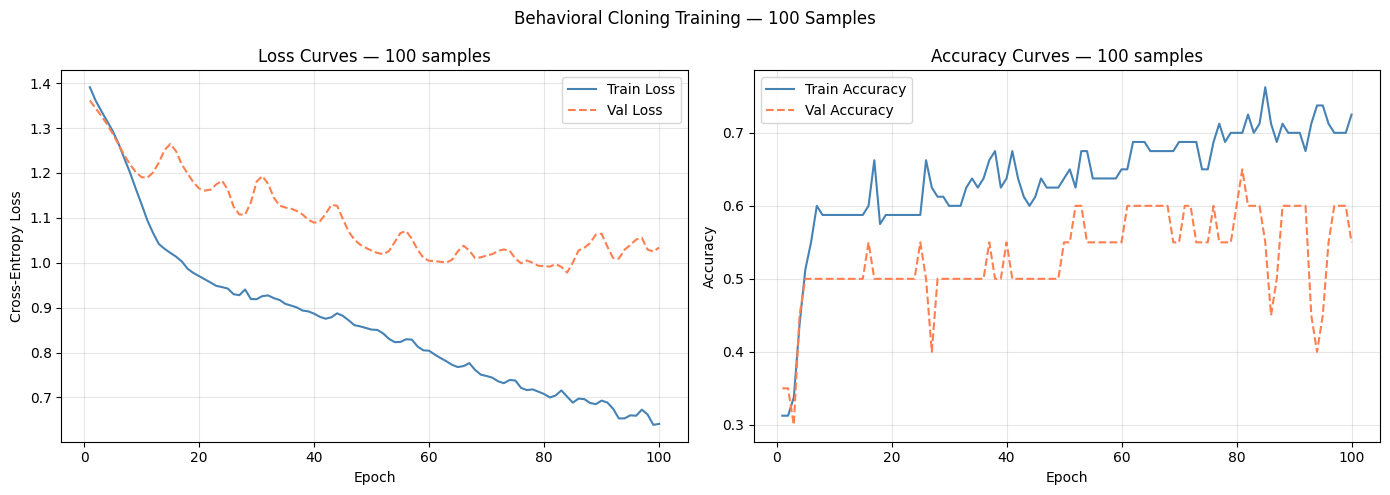

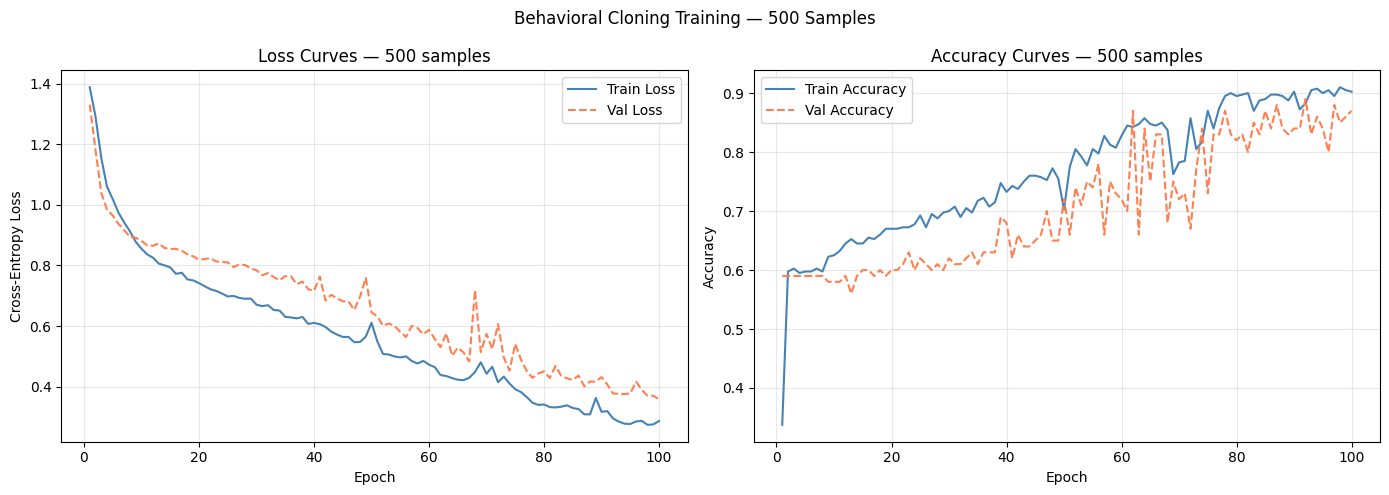

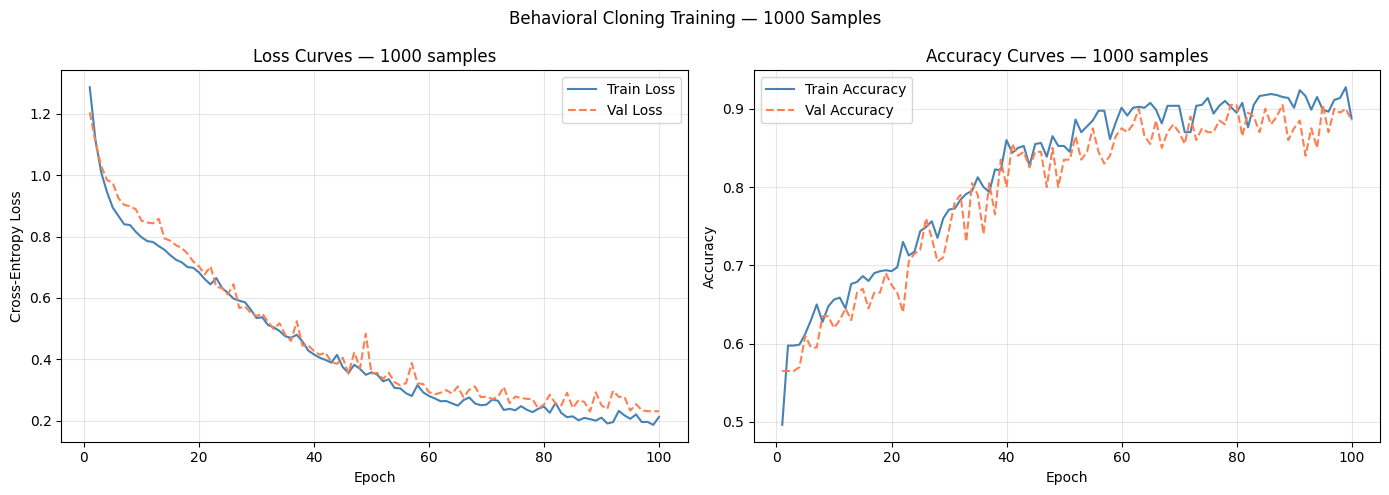

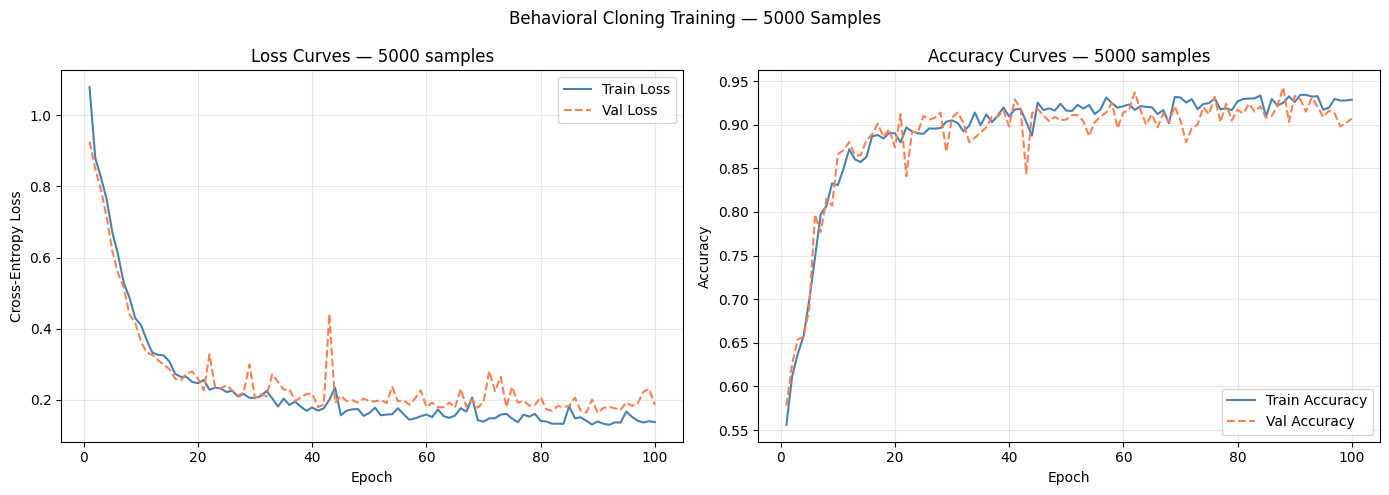

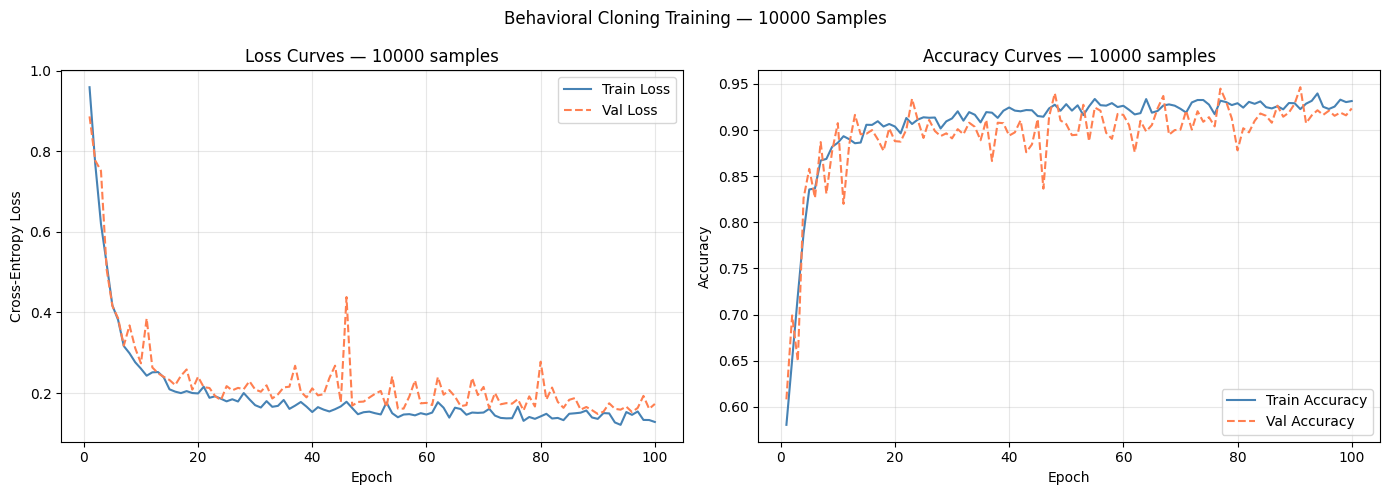

In [ ]:
# Plot training and validation curves
for dataset_size in DATASET_SIZES:
    main_history = history[dataset_size]
    plot_learning_curves(main_history, dataset_size)

### B3 — Evaluating the Imitation Model

We now deploy the trained imitation model as a policy in the LunarLander-v3 environment and measure:
- Reward distribution
- Average cumulative reward
- Episode length (steps until termination)
- Success rate (reward ≥ 200)
- Multi-Seed Stability
- Trajectory Comparison (compare paths till land)
- Action Distribution Shift

We compare these results against the expert agent.

In [ ]:
# Toolkit
def run_imitaion_episodes(model, env_name='LunarLander-v3', n_episodes=100, seed=42):
    """
    Roll out the model for n_episodes and record:
      - total reward per episode
      - episode length (steps)
      - cumulative reward trace per episode (for intra-episode plots)

    Returns
    -------
    rewards  : np.ndarray shape (n_episodes,)
    lengths  : np.ndarray shape (n_episodes,)
    traces   : list of np.ndarray, each shape (episode_length,)
    """
    eval_env = gym.make(env_name)
    rewards, lengths, traces = [], [], []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed + ep)
        done, ep_reward, ep_steps, cumulative = False, 0.0, 0, []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            ep_reward += reward
            ep_steps  += 1
            cumulative.append(ep_reward)

        rewards.append(ep_reward)
        lengths.append(ep_steps)
        traces.append(np.array(cumulative))

    eval_env.close()
    rewards, lengths = np.array(rewards), np.array(lengths)
    success_rate = (rewards >= 200).mean() * 100

    return {
        "rewards": rewards,
        "lengths": lengths,
        "mean_reward": rewards.mean(),
        "std_reward": rewards.std(),
        "mean_length": np.mean(lengths),
        "success_rate": success_rate,
        "traces": traces
    }

def evaluate_imitation_across_seeds(model, seeds=(0, 1, 2, 3, 4),
                           n_episodes_per_seed=20,
                           env_name='LunarLander-v3',
                           threshold=200, label='Expert'):
    """
    Evaluates the model independently for each seed and plots
    per-seed mean ± std. A robust expert should score consistently
    across different random initializations.
    """
    seed_means, seed_stds = [], []

    for seed in seeds:
        results = run_imitaion_episodes(model, env_name=env_name,
                                      n_episodes=n_episodes_per_seed, seed=seed)
        seed_means.append(results["mean_reward"])
        seed_stds.append(results["std_reward"])
        print(f'  Seed {seed}: {results["mean_reward"]:.1f} ± {results["std_reward"]:.1f} '
              f'| success: {results["success_rate"]}')

    fig, ax = plt.subplots(figsize=(8, 4))
    xs = list(range(len(seeds)))
    ax.bar(xs, seed_means, yerr=seed_stds, capsize=6,
           color='steelblue', alpha=0.8, width=0.5)
    ax.axhline(threshold, color='green', linestyle='--', lw=1.5,
               label=f'Imitation threshold ({threshold})')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'Seed {s}' for s in seeds])
    ax.set_ylabel('Mean Reward')
    ax.set_title('Imitation — Performance Across Seeds')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('Imitation_seed_stability.png', dpi=150)
    plt.show()
    return seed_means, seed_stds

def record_imitation_video(model, video_filename):
    """Records a single episode."""
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    frames = []
    obs, _ = env.reset(seed=42)
    done = False

    while not done:
        frames.append(env.render())
        action, _ = model.predict(obs) # Clean inference!
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()

    create_video(frames, video_filename, fps=30)


# ─────────────────────────────────────────────────────────────────────────────
# TOOL: FLIGHT TRAJECTORY COMPARISON (X, Y COORDS)
# ─────────────────────────────────────────────────────────────────────────────
def plot_trajectory_comparison(expert_model, bc_model, env_name='LunarLander-v3', seed=SEED):
    """
    Plots the physical flight path of both models starting from the exact same
    initial conditions.
    """
    env = gym.make(env_name)

    def get_trajectory(model):
        obs, _ = env.reset(seed=seed)
        done = False
        xs, ys = [obs[0]], [obs[1]] # LunarLander obs[0] is X, obs[1] is Y
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            xs.append(obs[0])
            ys.append(obs[1])
            done = terminated or truncated
        return xs, ys

    expert_x, expert_y = get_trajectory(expert_model)
    bc_x, bc_y = get_trajectory(bc_model)
    env.close()

    plt.figure(figsize=(8, 6))
    plt.plot(expert_x, expert_y, label='Expert Trajectory', color='navy', linewidth=2, linestyle='--')
    plt.plot(bc_x, bc_y, label='BC Model Trajectory', color='darkorange', linewidth=2)

    # Draw the landing pad flags (Approximate positions in LunarLander)
    plt.scatter([-0.2, 0.2], [0, 0], color='red', marker='^', s=100, label='Landing Flags')
    plt.axhline(0, color='gray', linestyle='-', alpha=0.5)

    plt.title('Flight Path Comparison: Expert vs Behavioral Cloning')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate (Altitude)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('trajectory_comparison.png', dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# TOOL: ACTION DISTRIBUTION COMPARISON
# ─────────────────────────────────────────────────────────────────────────────
def plot_action_distribution(expert_model, bc_model, env_name='LunarLander-v3', n_episodes=10):
    """
    Compares how frequently each model uses the different engines.
    """
    env = gym.make(env_name)

    def get_action_counts(model, is_expert):
        actions_taken = []
        for ep in range(n_episodes):
            obs, _ = env.reset(seed=42+ep)
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                actions_taken.append(int(action))
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
        return np.bincount(actions_taken, minlength=4)

    expert_counts = get_action_counts(expert_model, is_expert=True)
    bc_counts = get_action_counts(bc_model, is_expert=False)
    env.close()

    # Convert to percentages
    expert_pct = expert_counts / expert_counts.sum() * 100
    bc_pct = bc_counts / bc_counts.sum() * 100

    labels = ['Nothing (0)', 'Left Engine (1)', 'Main Engine (2)', 'Right Engine (3)']
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, expert_pct, width, label='Expert Model', color='navy', alpha=0.8)
    ax.bar(x + width/2, bc_pct, width, label='BC Model', color='darkorange', alpha=0.8)

    ax.set_ylabel('Percentage of Time Used (%)')
    ax.set_title('Engine Usage Comparison (Action Distribution)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('action_distribution.png', dpi=150)
    plt.show()


In [ ]:
imitation_model = ImitationNet()
imitation_model.load_state_dict(torch.load(f"./models/imitation/bc_model_5000.pt", map_location="cpu"))
imitation_model.eval()

imitation_history = run_imitaion_episodes(imitation_model)

# best_expert =
expert_rewards, expert_lengths, expert_cumulative = run_episodes(best_expert)

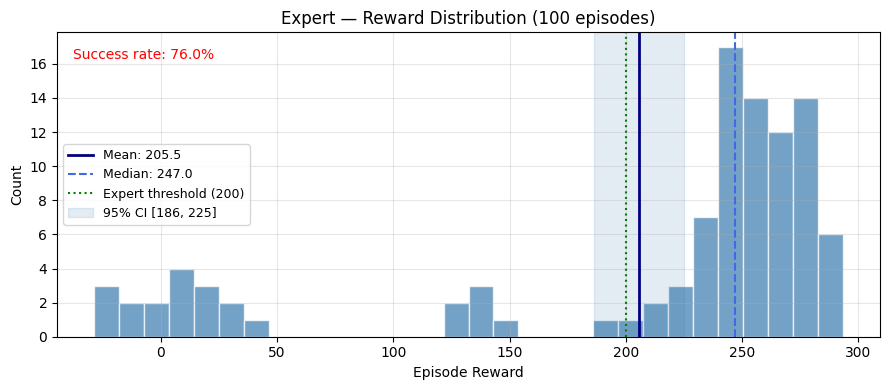

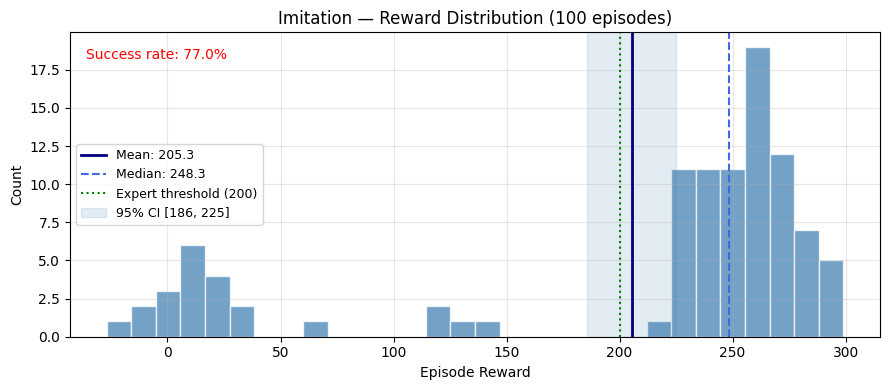

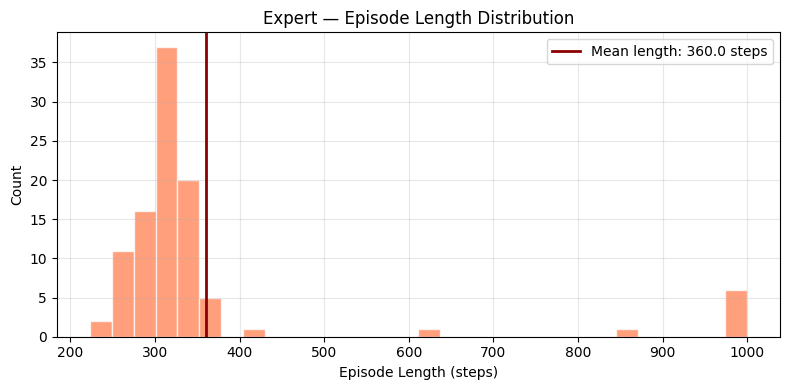

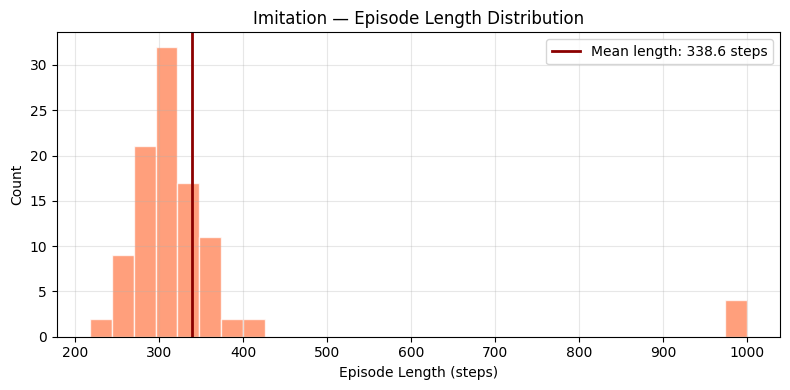

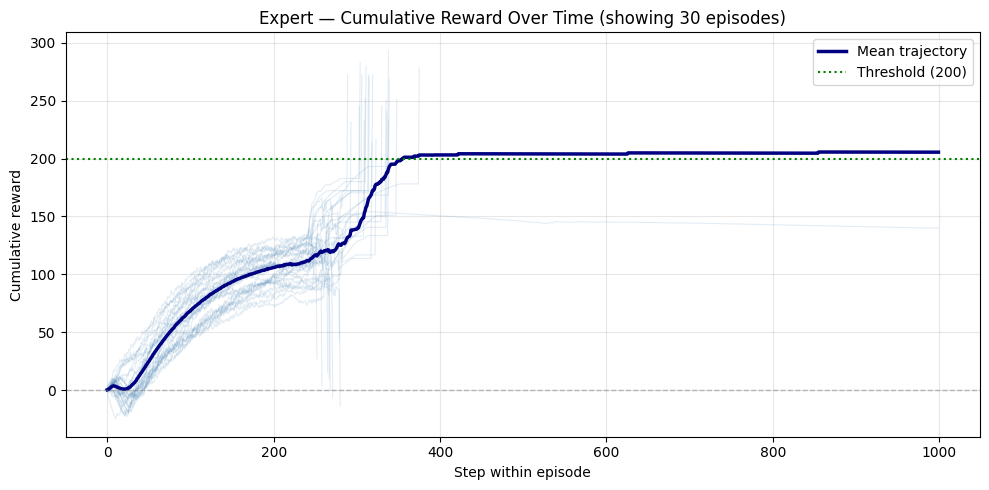

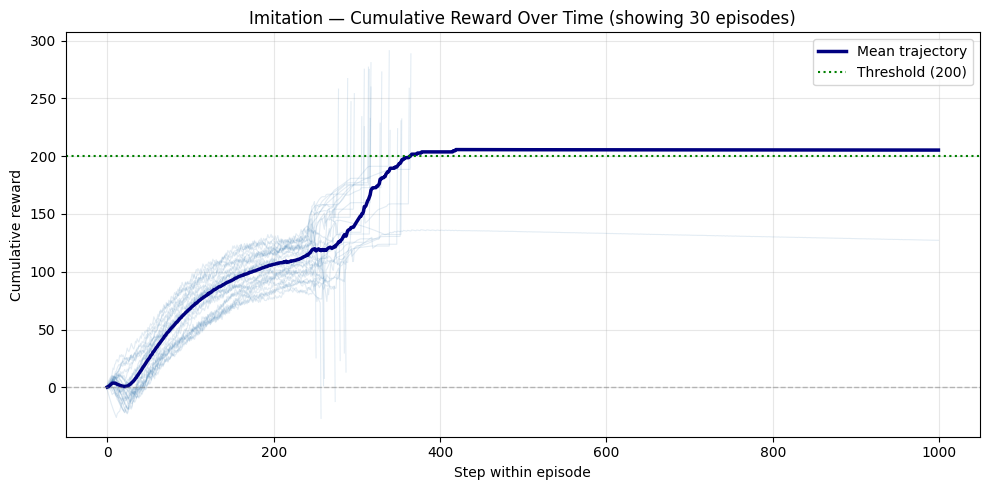

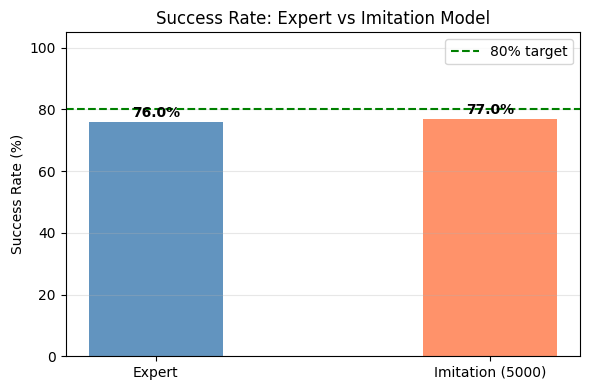

  Seed 0: 249.6 ± 23.8 | success: 100%
  Seed 1: 245.5 ± 34.4 | success: 95%
  Seed 2: 232.3 ± 67.2 | success: 90%
  Seed 3: 232.0 ± 67.2 | success: 90%


  return datetime.utcnow().replace(tzinfo=utc)



  Seed 4: 228.6 ± 69.7 | success: 85%


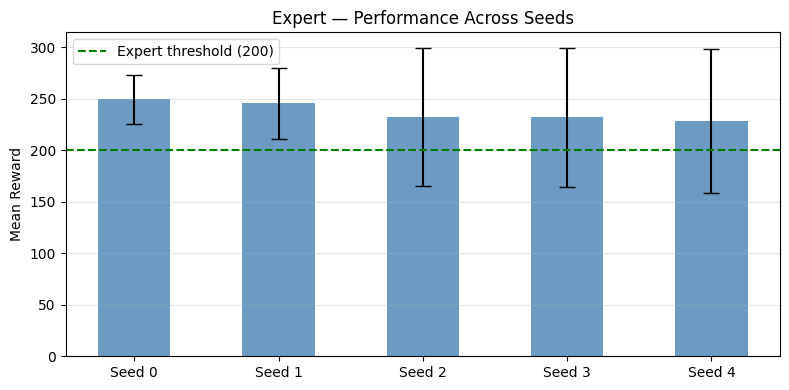

  Seed 0: 231.8 ± 58.0 | success: 90.0
  Seed 1: 217.5 ± 75.6 | success: 85.0
  Seed 2: 220.3 ± 77.5 | success: 85.0
  Seed 3: 220.8 ± 77.5 | success: 85.0


  return datetime.utcnow().replace(tzinfo=utc)



  Seed 4: 210.9 ± 88.7 | success: 80.0


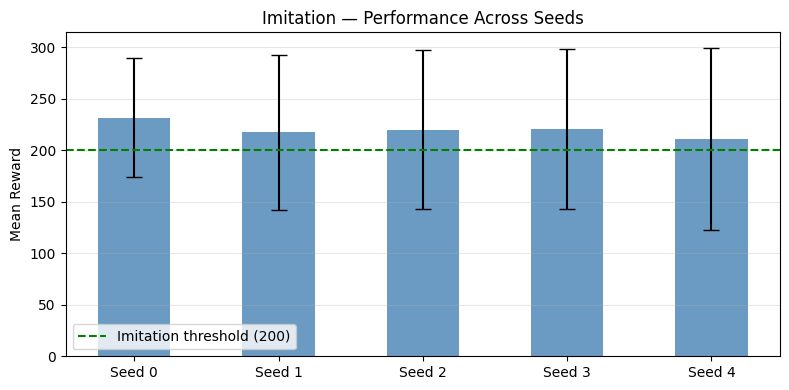

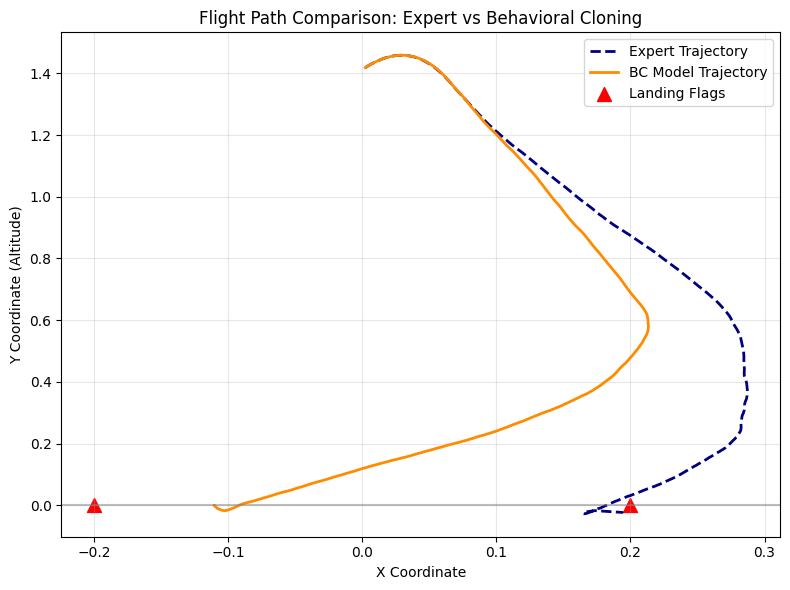

  return datetime.utcnow().replace(tzinfo=utc)



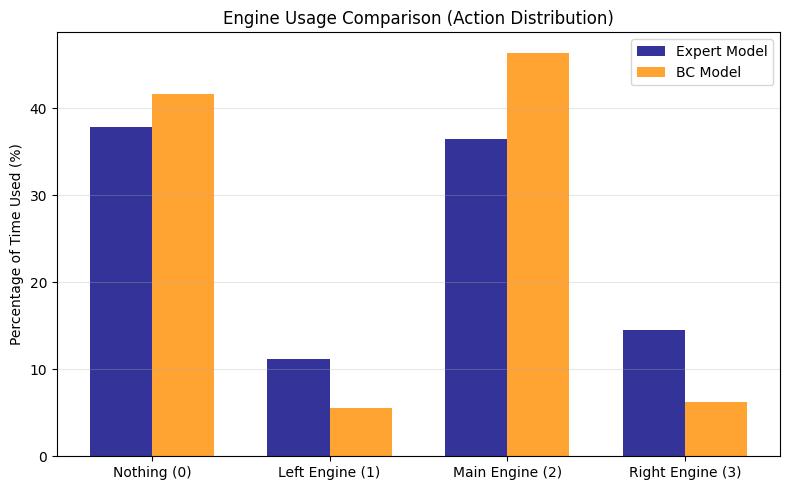

Moviepy - Building video imitation_5000_samples_video.mp4.
Moviepy - Writing video imitation_5000_samples_video.mp4



Moviepy - Done !
Moviepy - video ready imitation_5000_samples_video.mp4


In [ ]:
# Rewards Distribution
plot_reward_distribution(expert_rewards, threshold=200, label='Expert')
plot_reward_distribution(imitation_history["rewards"], threshold=200, label='Imitation')


# Episode Lengths
plot_episode_lengths(expert_lengths, label='Expert')
plot_episode_lengths(imitation_history["lengths"], label='Imitation')


# Cumulative Rewards
plot_cumulative_reward_traces(expert_cumulative, n_show=30, label='Expert')
plot_cumulative_reward_traces(imitation_history["traces"], n_show=30, label='Imitation')


# Success Rate
expert_success    = (expert_rewards >= 200).mean() * 100
imitation_success = imitation_history["success_rate"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Expert", "Imitation (5000)"],
       [expert_success, imitation_success],
       color=["steelblue", "coral"], alpha=0.85, width=0.4)
ax.axhline(80, color="green", linestyle="--", lw=1.5, label="80% target")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Success Rate: Expert vs Imitation Model")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate([expert_success, imitation_success]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("success_rate_comparison.png", dpi=150)
plt.show()


# Multi-Seed Stability
expert_means, expert_stds = evaluate_across_seeds(expert_model, label="Expert")
imitation_means, imitation_stds = evaluate_imitation_across_seeds(imitation_model, label="Imitation")


# FLIGHT TRAJECTORY COMPARISON (X, Y COORDS)
plot_trajectory_comparison(expert_model, imitation_model)


# ACTION DISTRIBUTION
plot_action_distribution(expert_model, imitation_model)


# Video
record_imitation_video(imitation_model, "imitation_5000_samples_video.mp4")

### B4 - analyzing the effects of dataset size


In [ ]:
valid_sizes = []
avg_rewards = []
success_rates = []
val_accuracies = []

for size in DATASET_SIZES:
    if size not in history:
        continue

    valid_sizes.append(size)

    # Validation Performance (using final epoch's validation accuracy)
    val_accuracies.append(history[size]["val_acc"][-1])

    # Load the corresponding model
    model = ImitationNet()
    model.load_state_dict(torch.load(f"./models/imitation/bc_model_{size}.pt", map_location="cpu"))
    model.eval()

    # Evaluate to get average reward and success rate
    print(f"Evaluating imitation model trained on {size} samples...")
    results = run_imitaion_episodes(model, n_episodes=100)
    avg_rewards.append(results["mean_reward"])
    success_rates.append(results["success_rate"])

Evaluating imitation model trained on 100 samples...
Evaluating imitation model trained on 500 samples...
Evaluating imitation model trained on 1000 samples...
Evaluating imitation model trained on 5000 samples...
Evaluating imitation model trained on 10000 samples...


  parse = parser.parseString(pattern)

  parser.resetCache()

  p.space          = oneOf(self._space_widths)("space")

  )("sym").leaveWhitespace()

  val.setName(key)

  val.setParseAction(getattr(self, key))

  p.text = cmd(r"\text", QuotedString('{', '\\', endQuoteChar="}"))

  p.math_string   = QuotedString('$', '\\', unquoteResults=False)

  result = self._expression.parseString(s)

  return fn(self, *args, **kwargs)

  ParserElement.resetCache()



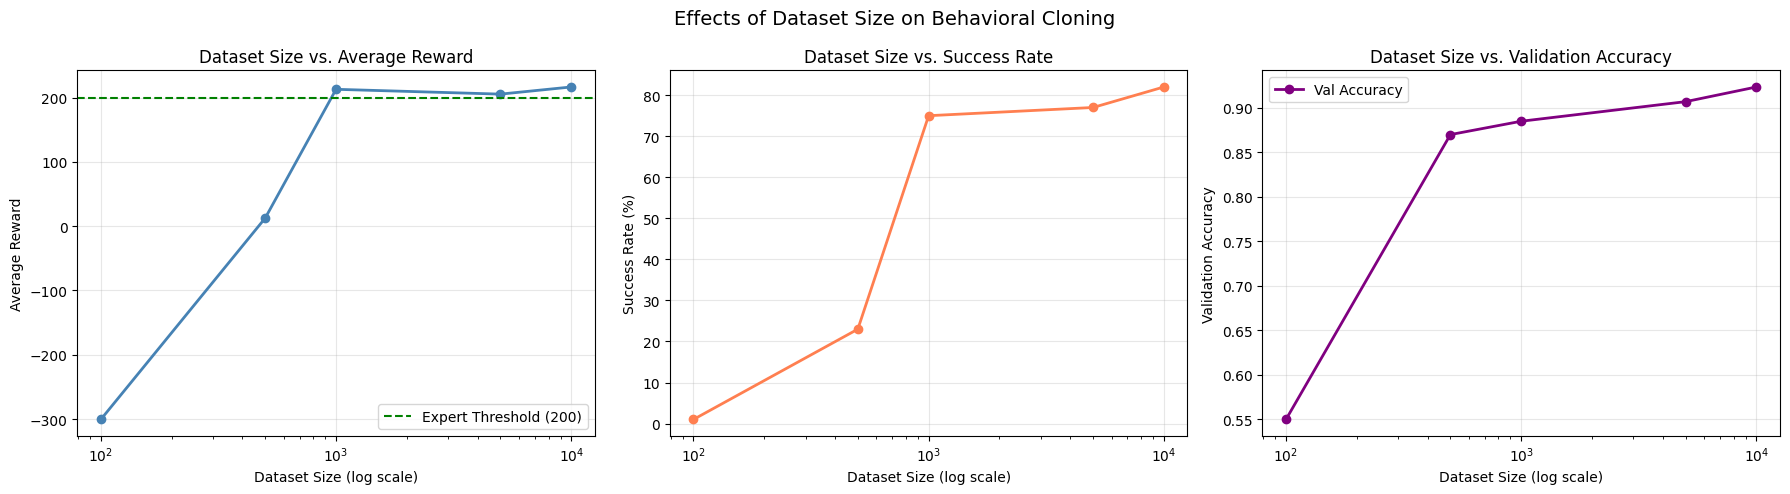

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Dataset Size vs. Average Reward
axes[0].plot(valid_sizes, avg_rewards, marker='o', color='steelblue', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_title('Dataset Size vs. Average Reward')
axes[0].set_xlabel('Dataset Size (log scale)')
axes[0].set_ylabel('Average Reward')
axes[0].axhline(200, color='green', linestyle='--', label='Expert Threshold (200)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Dataset Size vs. Success Rate
axes[1].plot(valid_sizes, success_rates, marker='o', color='coral', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('Dataset Size vs. Success Rate')
axes[1].set_xlabel('Dataset Size (log scale)')
axes[1].set_ylabel('Success Rate (%)')
axes[1].grid(True, alpha=0.3)

# 3. Dataset Size vs. Validation Performance
axes[2].plot(valid_sizes, val_accuracies, marker='o', color='purple', linewidth=2, label='Val Accuracy')
axes[2].set_xscale('log')
axes[2].set_title('Dataset Size vs. Validation Accuracy')
axes[2].set_xlabel('Dataset Size (log scale)')
axes[2].set_ylabel('Validation Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Effects of Dataset Size on Behavioral Cloning', fontsize=14)
plt.tight_layout()
plt.savefig('dataset_size_analysis.png', dpi=150)
plt.show()

In [ ]:
# Data set sizes Videos
for size in DATASET_SIZES:
    if size not in history:
        continue

    # Load the corresponding model
    model = ImitationNet()
    model.load_state_dict(torch.load(f"./models/imitation/bc_model_{size}.pt", map_location="cpu"))
    model.eval()

    record_imitation_video(model, f"comparison_{size}_samples_video.mp4")

Moviepy - Building video comparison_100_samples_video.mp4.
Moviepy - Writing video comparison_100_samples_video.mp4



Moviepy - Done !
Moviepy - video ready comparison_100_samples_video.mp4


Moviepy - Building video comparison_500_samples_video.mp4.
Moviepy - Writing video comparison_500_samples_video.mp4



Moviepy - Done !
Moviepy - video ready comparison_500_samples_video.mp4


Moviepy - Building video comparison_1000_samples_video.mp4.
Moviepy - Writing video comparison_1000_samples_video.mp4



Moviepy - Done !
Moviepy - video ready comparison_1000_samples_video.mp4


Moviepy - Building video comparison_5000_samples_video.mp4.
Moviepy - Writing video comparison_5000_samples_video.mp4



Moviepy - Done !
Moviepy - video ready comparison_5000_samples_video.mp4


Moviepy - Building video comparison_10000_samples_video.mp4.
Moviepy - Writing video comparison_10000_samples_video.mp4



Moviepy - Done !
Moviepy - video ready comparison_10000_samples_video.mp4


### B5 - Selecting a core set
In this section we study the effect of different data subset selection algorithms on the training

In [ ]:
# To prevent temporal leakage, we set aside the LAST 1,000 transitions for validation.
val_size_fixed = 1000

# Prepare Tensors for validation
val_states_fixed = torch.FloatTensor(all_states[-val_size_fixed:])
val_actions_fixed = torch.LongTensor(all_actions[-val_size_fixed:])
val_ds_fixed = TensorDataset(val_states_fixed, val_actions_fixed)
val_loader_fixed = DataLoader(val_ds_fixed, batch_size=256)

# The 'pool' for all few-shot strategies is the data collected BEFORE the validation window
pool_states = all_states[:-val_size_fixed]
pool_actions = all_actions[:-val_size_fixed]

print(f"Validation set: {len(val_states_fixed)} samples (chronological end of expert data)")
print(f"Training pool: {len(pool_states)} samples available for selection strategies")

FEW_SHOT_SIZES = [2, 5, 10, 20, 50, 100, 500, 1000]

Validation set: 1000 samples (chronological end of expert data)
Training pool: 69573 samples available for selection strategies


In [ ]:
def train_few_shot_subset(X_train, y_train, val_loader, device="cpu", epochs=200):
    """
    A single, unified training loop used by ALL few-shot strategies.
    Takes pre-selected data, trains a model, and returns the history.
    """
    model = ImitationNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Convert to Tensors
    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.LongTensor(y_train)

    train_ds = TensorDataset(X_tensor, y_tensor)

    # Dynamic batch size handles extremely small subsets safely
    active_loader = DataLoader(train_ds, batch_size=min(len(X_train), 32), shuffle=True)

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        # --- Training Step ---
        model.train()
        t_loss, t_corr, t_total = 0, 0, 0

        for xb, yb in active_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            t_loss += loss.item() * xb.size(0)
            t_corr += (out.argmax(1) == yb).sum().item()
            t_total += xb.size(0)

        # --- Validation Step ---
        model.eval()
        v_loss, v_corr, v_total = 0, 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                v_loss += criterion(out, yb).item() * xb.size(0)
                v_corr += (out.argmax(1) == yb).sum().item()
                v_total += xb.size(0)

        hist["train_loss"].append(t_loss / t_total)
        hist["train_acc"].append(t_corr / t_total)
        hist["val_loss"].append(v_loss / v_total)
        hist["val_acc"].append(v_corr / v_total)

    return model, hist

In [ ]:
def plot_training_health_detailed(train_history, method):
    sorted_sizes = sorted(train_history.keys())
    n_models = len(sorted_sizes)
    cols = 4
    rows = (n_models + cols - 1) // cols

    # Plot 1: Accuracy (Train & Val)
    fig_acc, axes_acc = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes_acc = axes_acc.flatten()

    # Plot 2: Loss (Train & Val)
    fig_loss, axes_loss = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes_loss = axes_loss.flatten()

    for i, size in enumerate(sorted_sizes):
        hist = train_history[size]
        epochs = range(1, len(hist['train_acc']) + 1)

        # Accuracy Subplot
        ax_acc = axes_acc[i]
        ax_acc.plot(epochs, hist['train_acc'], color='blue', label='Train Acc', linewidth=2)
        ax_acc.plot(epochs, hist['val_acc'], color='orange', label='Val Acc', linestyle='--', linewidth=2)
        ax_acc.set_title(f'Accuracy (Size: {size})')
        ax_acc.set_ylim(0, 1.1)
        ax_acc.grid(True, alpha=0.3)
        ax_acc.legend(loc='lower right')

        # Loss Subplot
        ax_loss = axes_loss[i]
        ax_loss.plot(epochs, hist['train_loss'], color='red', label='Train Loss', linewidth=2)
        ax_loss.plot(epochs, hist['val_loss'], color='darkred', label='Val Loss', linestyle='--', linewidth=2)
        ax_loss.set_title(f'Loss (Size: {size})')
        ax_loss.grid(True, alpha=0.3)
        ax_loss.legend(loc='upper right')

    # Cleanup empty plots
    for j in range(i + 1, len(axes_acc)):
        axes_acc[j].axis('off')
        axes_loss[j].axis('off')

    fig_acc.suptitle(f'{method}: Accuracy Health', fontsize=16)
    fig_loss.suptitle(f'{method}: Loss Health', fontsize=16)
    plt.show()

In [ ]:
def evaluate_strategy(strategy_name, datasets_dict, val_loader, few_shot_sizes, device="cpu", epochs=200):
    """
    Refactored: Iterates over all sizes, trains the models, aggregates
    all histories, and then plots the complete health grid.
    """
    print(f"\n========================================")
    print(f" Evaluating Strategy: {strategy_name}")
    print(f"========================================")

    strategy_history = {}

    for size in few_shot_sizes:
        print(f"--- Training Budget Size: {size} ---")

        # Extract the pre-selected subset
        X_train = datasets_dict[size]["states"]
        y_train = datasets_dict[size]["actions"]

        # Train using the unified engine
        model, hist = train_few_shot_subset(X_train, y_train, val_loader, device, epochs)

        # Log results for this specific size
        strategy_history[size] = hist

        # Save the model
        safe_name = strategy_name.replace(" ", "_").lower()
        torch.save(model.state_dict(), f"./models/imitation/{safe_name}_model_{size}.pt")
        print(f"  Saved: {safe_name}_model_{size}.pt")

    # After all sizes are trained, plot the full health grid
    print(f"\nGenerating training health plots for {strategy_name}...")
    plot_training_health_detailed(strategy_history, strategy_name)

    return strategy_history

#### Random
The baseline method samples randomly for a data subset

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def random_sampling(size, pool_states, pool_actions):
    """
    Returns a flat dictionary containing states and actions
    for the requested budget size using a fixed seed.
    """
    # Use a generator with a fixed seed for deterministic sampling
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(pool_states), size=size, replace=False)
    subset = {
        "states": pool_states[idx],
        "actions": pool_actions[idx]
    }
    print(f"Random few-shot dataset created for size {size}.")
    return subset

Random few-shot dataset created for size 2.
Random few-shot dataset created for size 5.
Random few-shot dataset created for size 10.
Random few-shot dataset created for size 20.
Random few-shot dataset created for size 50.
Random few-shot dataset created for size 100.
Random few-shot dataset created for size 500.
Random few-shot dataset created for size 1000.

 Evaluating Strategy: Random
--- Training Budget Size: 2 ---
  Saved: random_model_2.pt
--- Training Budget Size: 5 ---
  Saved: random_model_5.pt
--- Training Budget Size: 10 ---
  Saved: random_model_10.pt
--- Training Budget Size: 20 ---
  Saved: random_model_20.pt
--- Training Budget Size: 50 ---
  Saved: random_model_50.pt
--- Training Budget Size: 100 ---
  Saved: random_model_100.pt
--- Training Budget Size: 500 ---
  Saved: random_model_500.pt
--- Training Budget Size: 1000 ---
  Saved: random_model_1000.pt

Generating training health plots for Random...


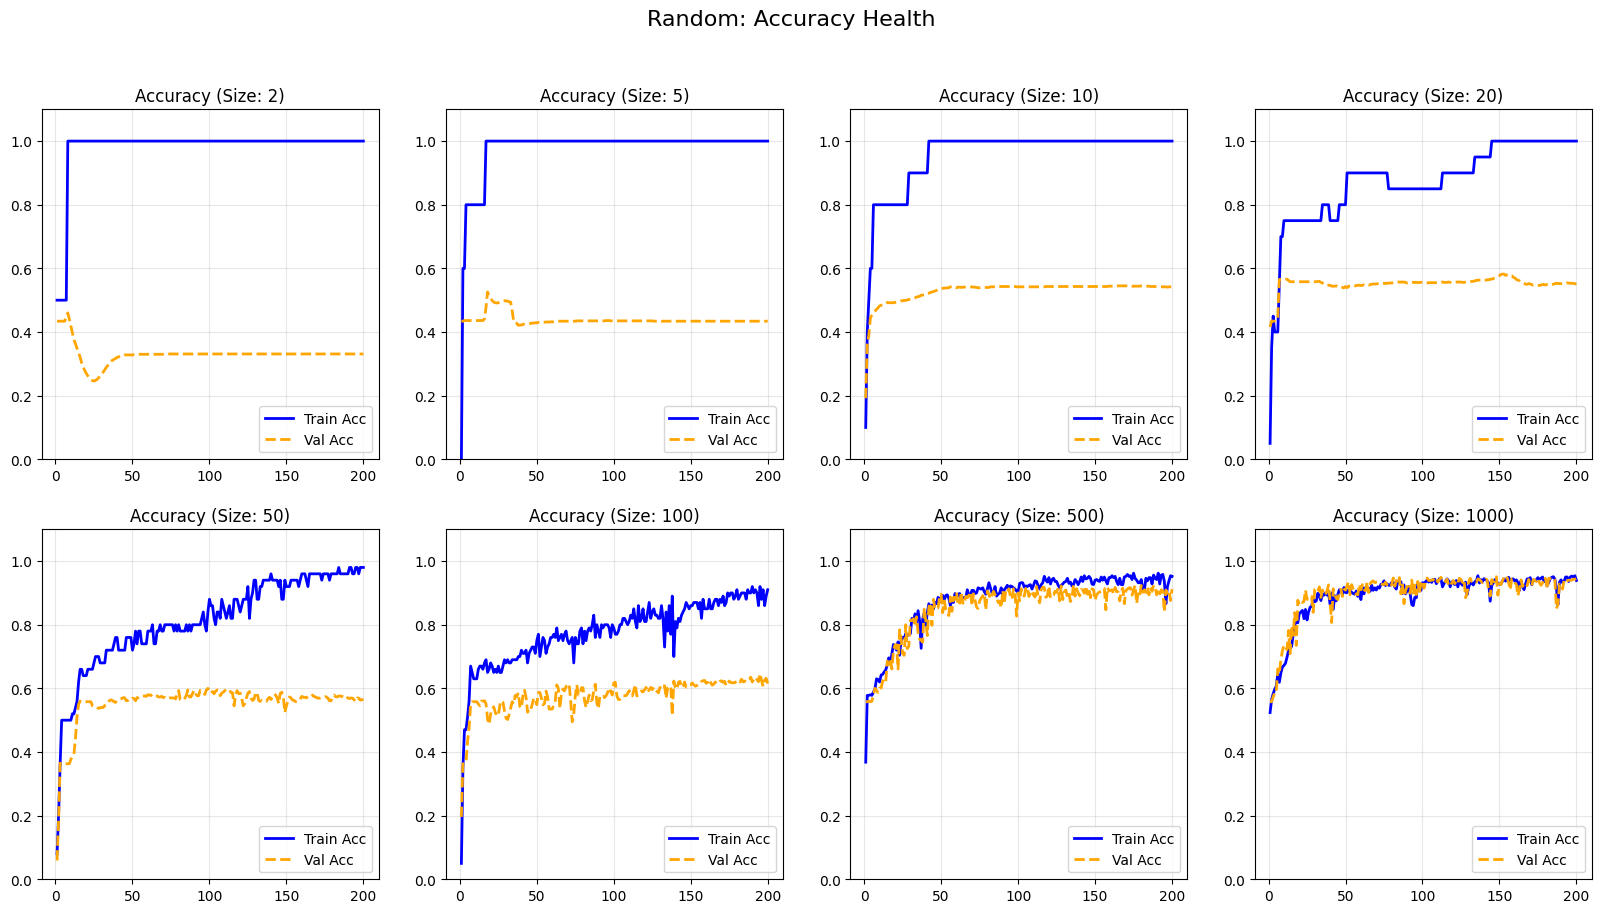

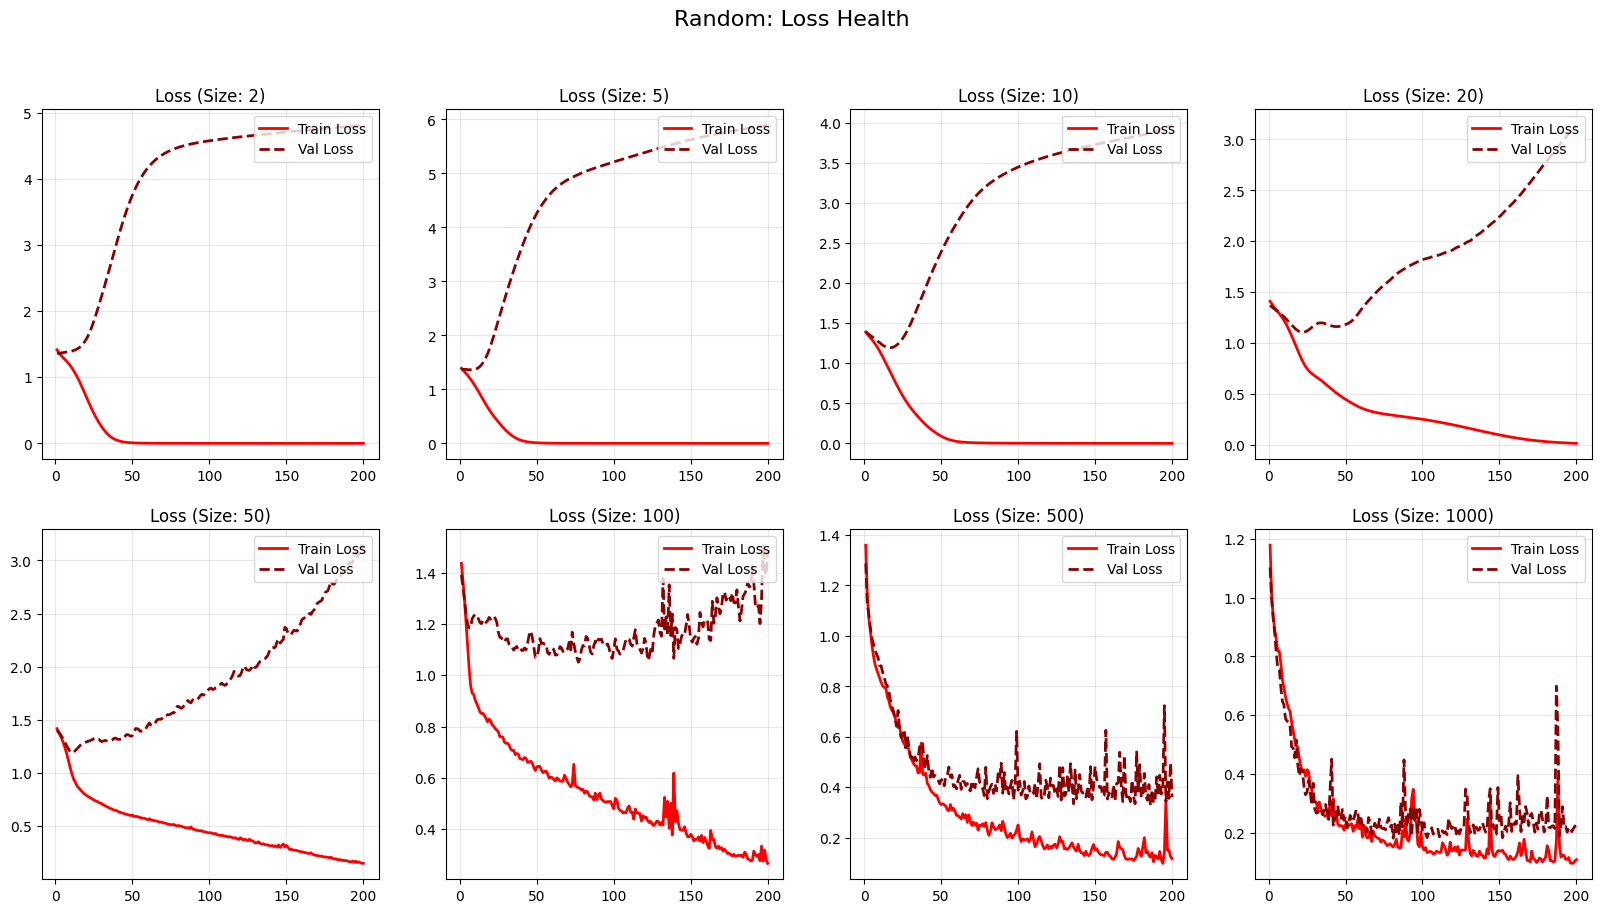

In [ ]:
random_datasets = {}
for size in FEW_SHOT_SIZES:
    # Now returns {'states': ..., 'actions': ...} directly
    random_datasets[size] = random_sampling(size, pool_states, pool_actions)

# This will now find the 'states' key correctly
random_history = evaluate_strategy("Random", random_datasets, val_loader_fixed, FEW_SHOT_SIZES, device)

#### Stratified Domain Knowledge Strategy

This strategy filters the data to include only transitions from successful episodes (reward ≥ 200) and then balances the core set across:
1.  **Actions**: Ensuring all 4 discrete actions are represented.
2.  **Spatial Coordinates**: Binning $x$ (horizontal) and $y$ (vertical) positions to ensure the model sees diverse landing and flight scenarios.

In [ ]:
def select_stratified_domain_knowledge(size, states, actions, rewards_per_step=None):
    """
    Strategy:
    1. Bin X and Y coordinates to ensure spatial coverage.
    2. Sample uniformly across (Action, X-Bin, Y-Bin) combinations using fixed SEED.
    """
    # Fix seed for any internal numpy calls
    rng = np.random.default_rng(SEED)

    # Create a DataFrame for easier grouping
    df = pd.DataFrame(states[:, :2], columns=['x', 'y'])
    df['action'] = actions

    # Create spatial bins
    df['x_bin'] = pd.qcut(df['x'], 5, labels=False, duplicates='drop')
    df['y_bin'] = pd.qcut(df['y'], 5, labels=False, duplicates='drop')

    # Combine features for stratification
    df['stratify_key'] = df['action'].astype(str) + '_' + df['x_bin'].astype(str) + '_' + df['y_bin'].astype(str)

    unique_keys = df['stratify_key'].unique()
    indices = []

    # Simple round-robin sampling across stratified keys
    while len(indices) < size:
        rng.shuffle(unique_keys)
        for key in unique_keys:
            if len(indices) >= size: break
            key_indices = df[df['stratify_key'] == key].index.values
            available = np.setdiff1d(key_indices, indices)
            if len(available) > 0:
                indices.append(rng.choice(available))

    return {
        "states": states[indices],
        "actions": actions[indices]
    }

  return datetime.utcnow().replace(tzinfo=utc)




 Evaluating Strategy: Domain Knowledge
--- Training Budget Size: 2 ---
  Saved: domain_knowledge_model_2.pt
--- Training Budget Size: 5 ---
  Saved: domain_knowledge_model_5.pt
--- Training Budget Size: 10 ---
  Saved: domain_knowledge_model_10.pt
--- Training Budget Size: 20 ---
  Saved: domain_knowledge_model_20.pt
--- Training Budget Size: 50 ---
  Saved: domain_knowledge_model_50.pt
--- Training Budget Size: 100 ---
  Saved: domain_knowledge_model_100.pt
--- Training Budget Size: 500 ---
  Saved: domain_knowledge_model_500.pt
--- Training Budget Size: 1000 ---
  Saved: domain_knowledge_model_1000.pt

Generating training health plots for Domain Knowledge...


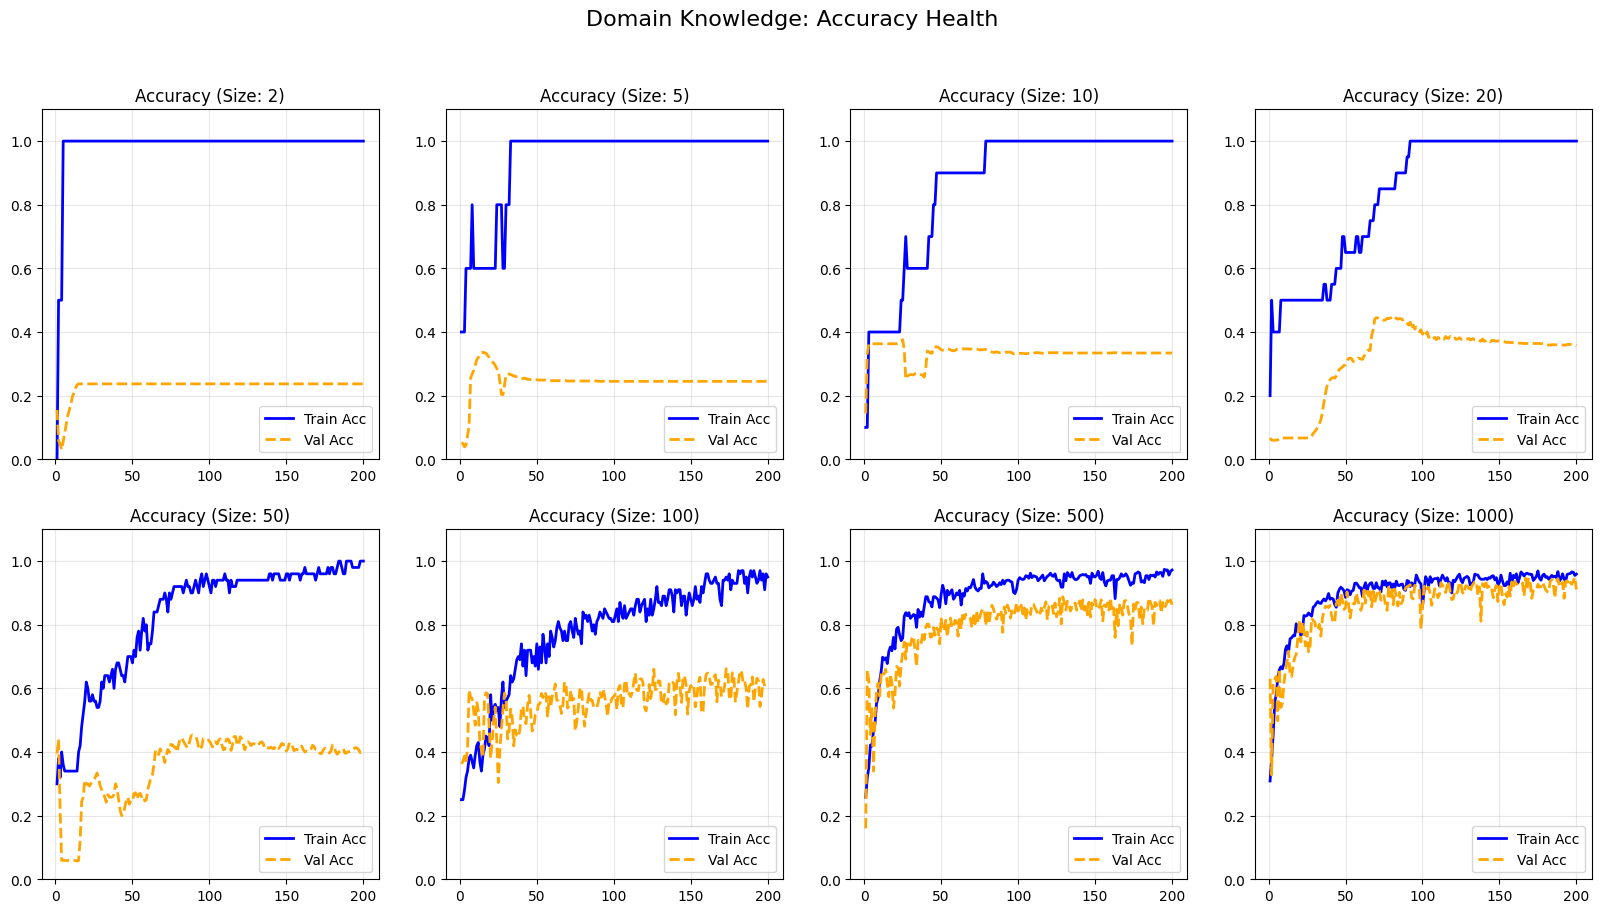

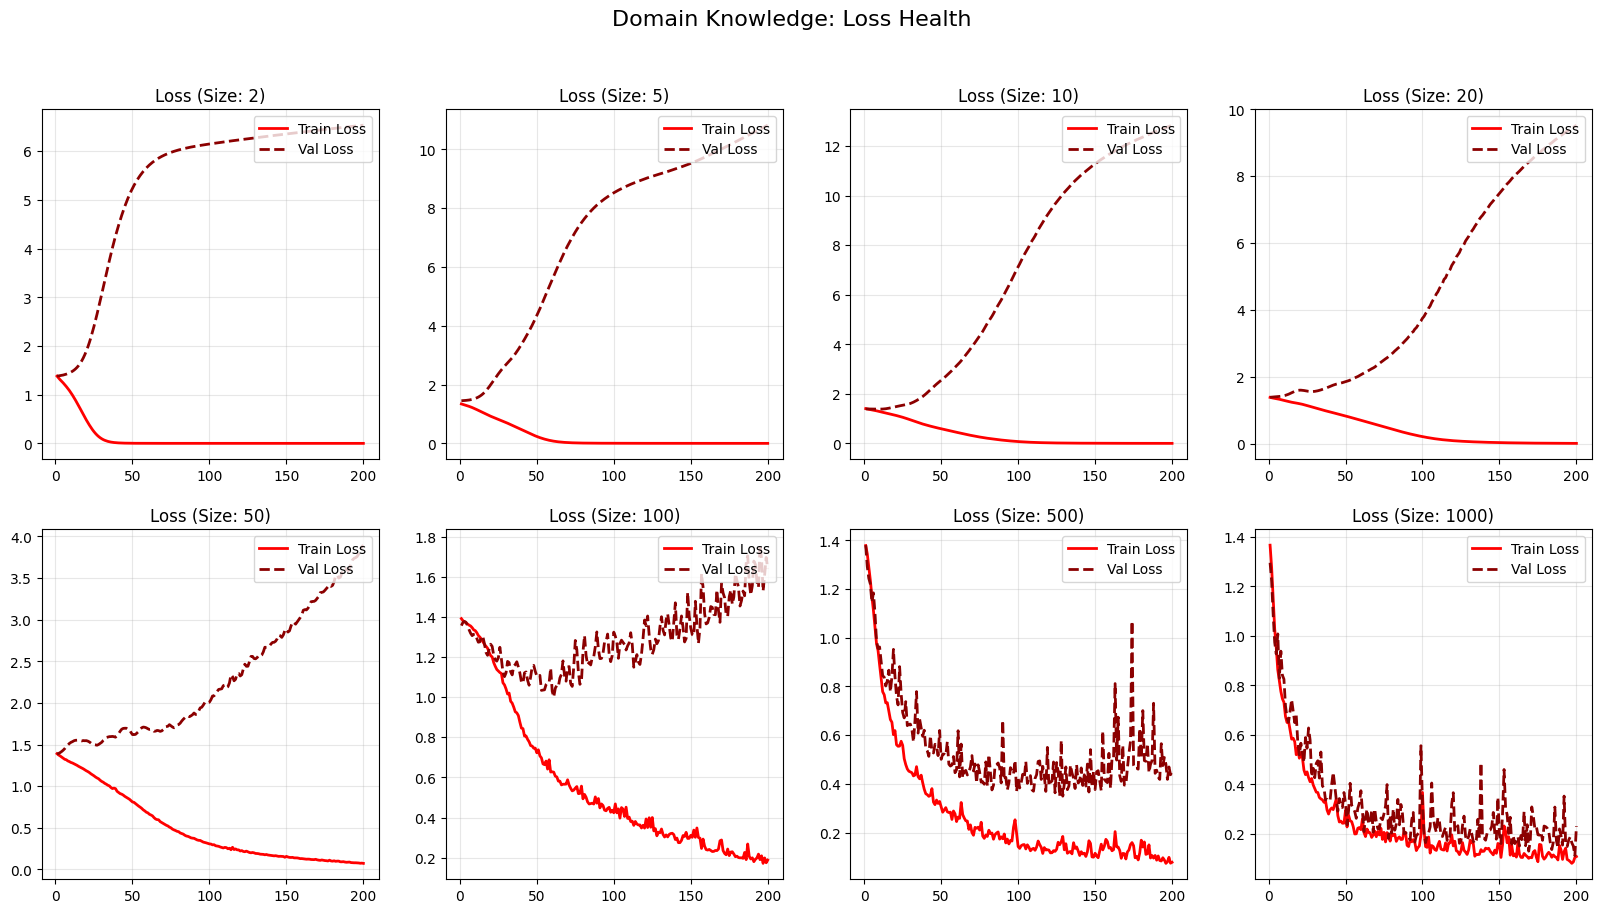

In [ ]:
# 1. Build Datasets
domain_knowledge_datasets = {}
for size in FEW_SHOT_SIZES:
    domain_knowledge_datasets[size] = select_stratified_domain_knowledge(size, pool_states, pool_actions)

# 2. Evaluate
domain_history = evaluate_strategy("Domain Knowledge", domain_knowledge_datasets, val_loader_fixed, FEW_SHOT_SIZES, device)

#### K-center greedy (on the expert's embedding space)
In this strategy we use the expert's world knowledge and understanding of the task, to search for meaningful datapoints.
Specifically, we use the expert's latent space, assuming it represents the data points geometrically in a way that encodes their relation to each other and their importance for the task.

On this embedding space we perform the K-Center Greedy algorithm:
1. Pick a random point $c$ and add it to the centers $S$.
2. For every point $p$ in the dataset, find the nearest center $c_{min}=d(p,S)=\min_{c\in S}{dist(p,c)}$
3. Pick a new point $p$ which is the **furthest** from $c_{min}$: $p_{far}=max_{p\in S}d(p,S)$
4. Add the new point as the next center $S=S\cup \{p_{far}\}$

This algorithm outputs k centers that cover most of the data landscape (minimizing the distance of any point to the closest center).


In [ ]:
def k_center_greedy(features, budget):
    """
    Selects a diverse core-set by maximizing the minimum distance between points.
    Uses fixed SEED for the initial center.
    """
    rng = np.random.default_rng(SEED)
    N = features.shape[0]
    selected_indices = []

    current_center = rng.integers(0, N)
    selected_indices.append(current_center)

    min_distances = np.linalg.norm(features - features[current_center], axis=1)

    for _ in range(1, budget):
        new_center = np.argmax(min_distances)
        selected_indices.append(new_center)

        new_distances = np.linalg.norm(features - features[new_center], axis=1)
        min_distances = np.minimum(min_distances, new_distances)

    return np.array(selected_indices)

#### K means (on the expert's embedding space)
In this algorithm we also search for centers on the expert's embedding space.

1. Pick a random k points and add assign them as centers $S$.
2. For every point $p$ in the dataset, assign it to the cluster of the nearest center.
3. For every cluster, compute the new center as the mean of the points assigned to the cluster
4. Repeat until convergence

This algorithm captures the natural data distribution (in the expert's embedding space) and finds clusters that contain similar points w.r.t. the task. That allows us to use one center instead of many similar data points in that cluster.

In [ ]:
def k_means_coreset(features, budget):
    """
    Selects a density-aware core-set by finding the K-Means cluster centers.
    Uses fixed SEED for the KMeans algorithm.
    """
    # Force deterministic KMeans behavior
    kmeans = KMeans(n_clusters=budget, init='k-means++', n_init=10, random_state=SEED)
    kmeans.fit(features)

    closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, features)

    return closest_indices

Once again, we use the same stratification logic to balance the data, making sure we sample evenly from all of the classes (actions) and a variety of states

In [ ]:
def select_stratified_geometric_coreset(actions, embeddings, budget, strategy_fn):
    """
    Safely allocates the budget across classes and executes the chosen geometric strategy.
    Now includes a fixed shuffle at the end.
    """
    rng = np.random.default_rng(SEED)
    unique_actions = np.unique(actions)
    num_classes = len(unique_actions)

    base_budget = budget // num_classes
    remainder = budget % num_classes

    global_selected_indices = []

    for i, action_val in enumerate(unique_actions):
        class_budget = base_budget + (1 if i < remainder else 0)
        class_mask = np.where(actions == action_val)[0]

        if len(class_mask) == 0 or class_budget == 0:
            continue

        class_embeddings = embeddings[class_mask]
        actual_class_budget = min(class_budget, len(class_mask))

        if actual_class_budget == len(class_mask):
            local_indices = np.arange(len(class_mask))
        else:
            local_indices = strategy_fn(class_embeddings, actual_class_budget)

        global_indices = class_mask[local_indices]
        global_selected_indices.extend(global_indices)

    global_selected_indices = np.array(global_selected_indices)
    # Final deterministic shuffle
    rng.shuffle(global_selected_indices)

    return global_selected_indices

In [ ]:
def extract_expert_embeddings(states, expert_model, extract_layer, device="cpu"):
    """
    Passes the offline states through the PPO Expert to extract latent embeddings.
    Uses forward hooks to grab the activations from the specified hidden layer.
    """
    expert_model.policy.eval()
    X = torch.FloatTensor(states).to(device)

    embeddings = []
    def hook(module, input, output):
        # We grab the output of the layer and move it to CPU numpy for Scikit-Learn
        embeddings.append(output.detach().cpu().numpy())

    handle = extract_layer.register_forward_hook(hook)

    # Process in batches to avoid OOM errors on large offline pools
    batch_size = 1024
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            embeddings.clear()
            # Pass through the policy to trigger the hook
            expert_model.policy(X[i:i+batch_size])
            # The hook populates the list; we append the first (and only) item
            all_embeddings.append(embeddings[0])

    handle.remove()
    return np.concatenate(all_embeddings, axis=0)

In [ ]:
# Helper to build datasets for any geometric strategy
def build_geometric_datasets(strategy_func, embeddings, pool_states, pool_actions, few_shot_sizes):
    datasets = {}
    for size in few_shot_sizes:
        core_indices = select_stratified_geometric_coreset(
            actions=pool_actions, embeddings=embeddings, budget=size, strategy_fn=strategy_func
        )
        datasets[size] = {
            "states": pool_states[core_indices],
            "actions": pool_actions[core_indices]
        }
    return datasets

  return datetime.utcnow().replace(tzinfo=utc)

  return datetime.utcnow().replace(tzinfo=utc)

  return datetime.utcnow().replace(tzinfo=utc)

  return datetime.utcnow().replace(tzinfo=utc)




 Evaluating Strategy: Stratified K-Means
--- Training Budget Size: 2 ---
  Saved: stratified_k-means_model_2.pt
--- Training Budget Size: 5 ---
  Saved: stratified_k-means_model_5.pt
--- Training Budget Size: 10 ---
  Saved: stratified_k-means_model_10.pt
--- Training Budget Size: 20 ---
  Saved: stratified_k-means_model_20.pt
--- Training Budget Size: 50 ---
  Saved: stratified_k-means_model_50.pt
--- Training Budget Size: 100 ---
  Saved: stratified_k-means_model_100.pt
--- Training Budget Size: 500 ---
  Saved: stratified_k-means_model_500.pt
--- Training Budget Size: 1000 ---
  Saved: stratified_k-means_model_1000.pt

Generating training health plots for Stratified K-Means...


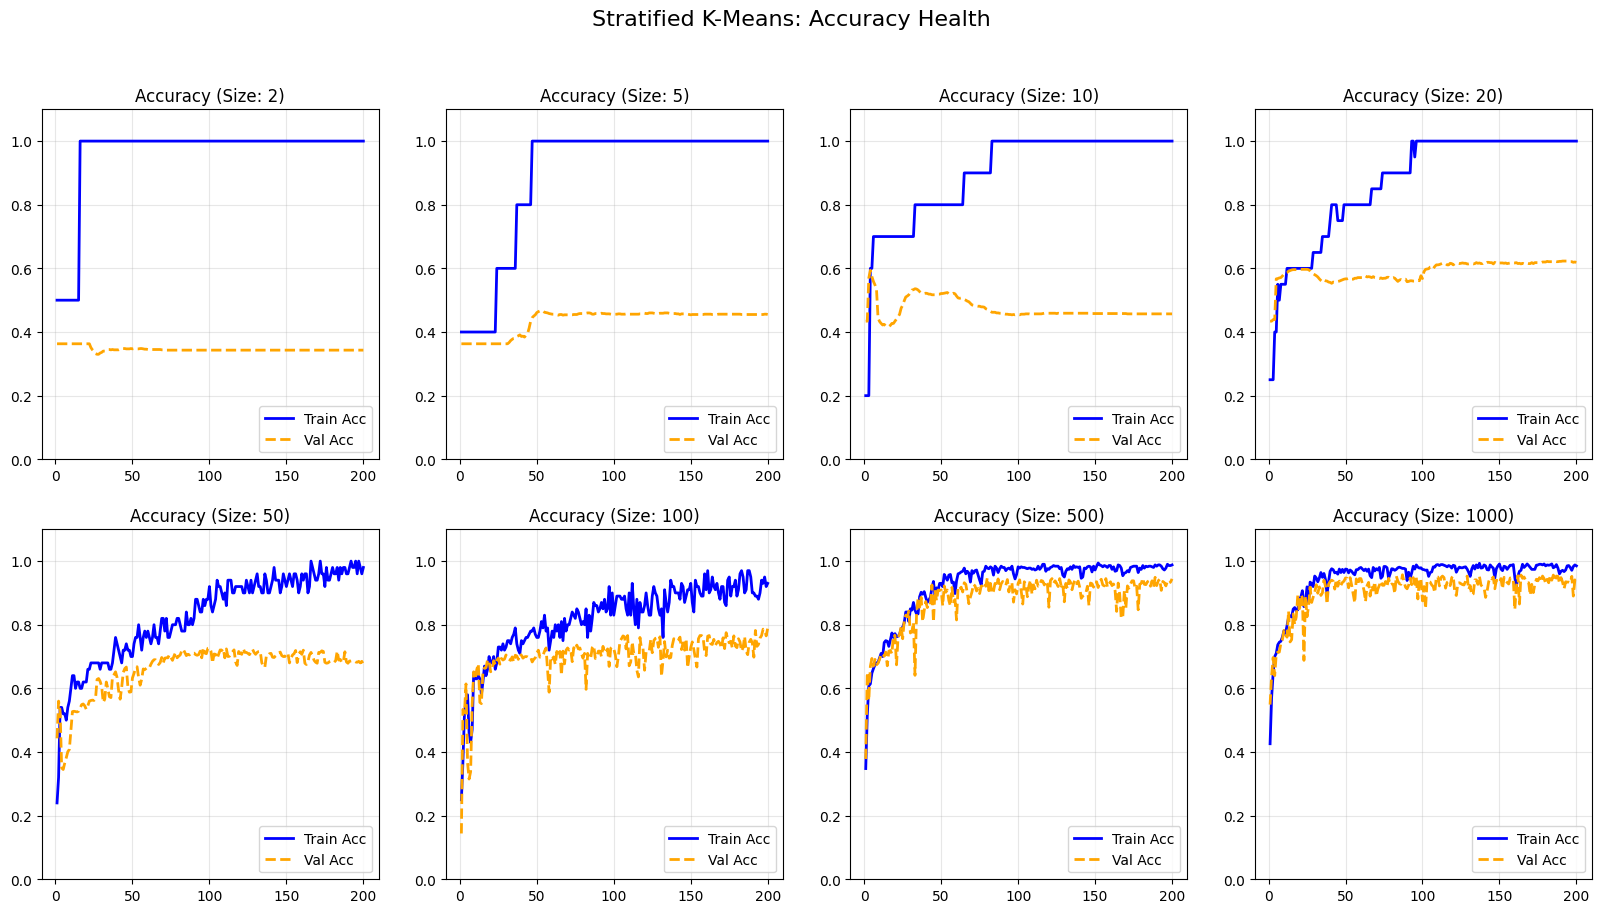

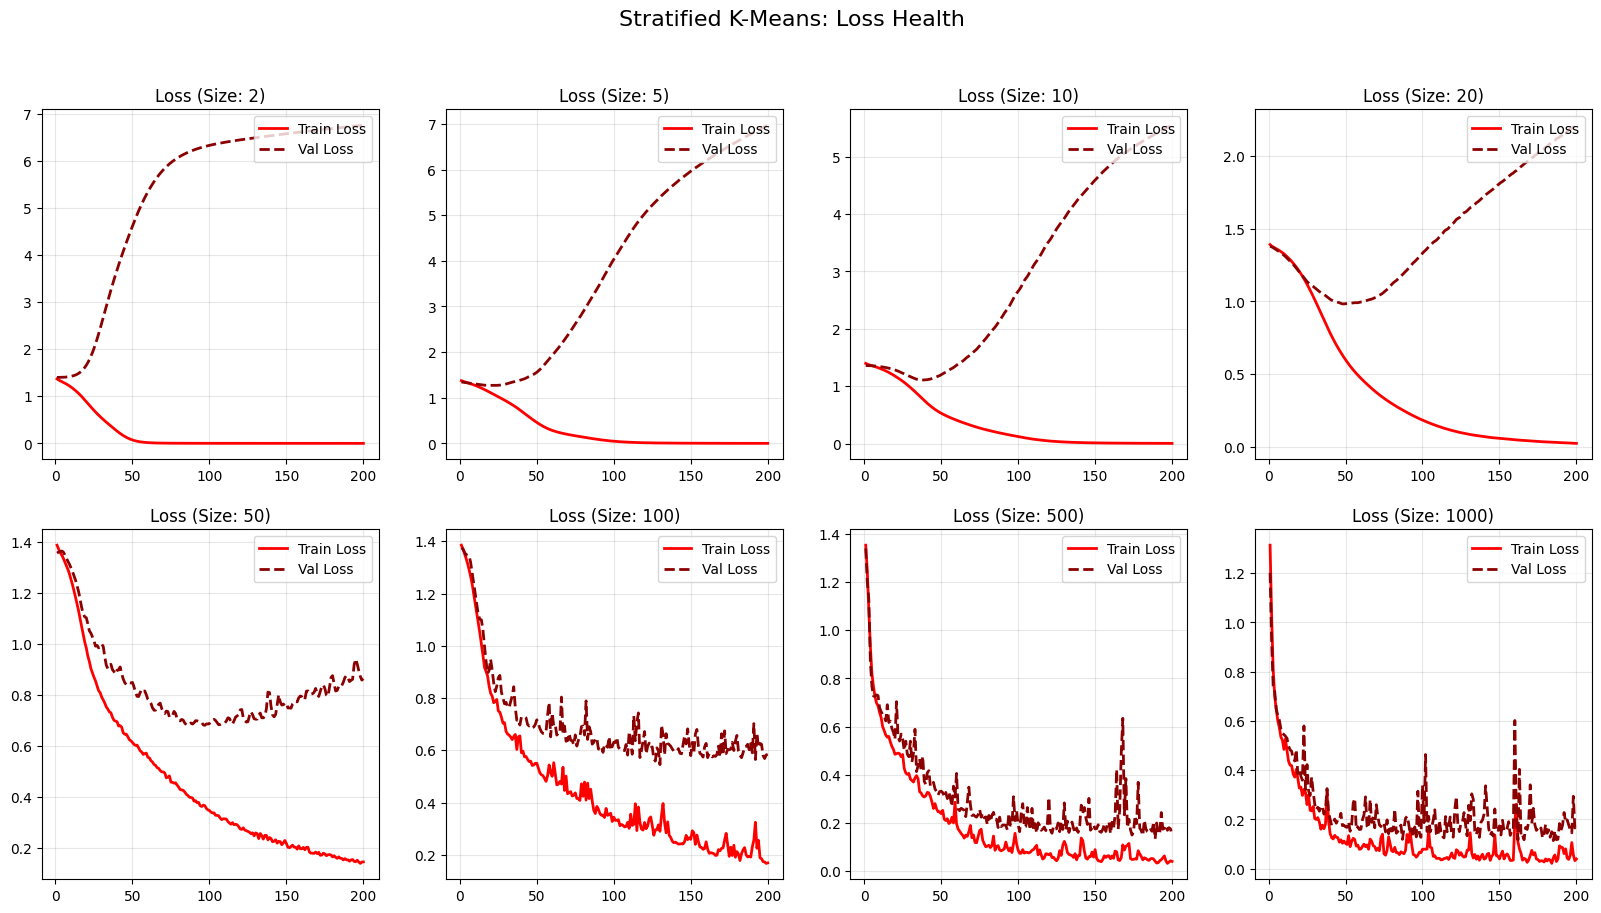


 Evaluating Strategy: Stratified k-Center
--- Training Budget Size: 2 ---
  Saved: stratified_k-center_model_2.pt
--- Training Budget Size: 5 ---
  Saved: stratified_k-center_model_5.pt
--- Training Budget Size: 10 ---
  Saved: stratified_k-center_model_10.pt
--- Training Budget Size: 20 ---
  Saved: stratified_k-center_model_20.pt
--- Training Budget Size: 50 ---
  Saved: stratified_k-center_model_50.pt
--- Training Budget Size: 100 ---
  Saved: stratified_k-center_model_100.pt
--- Training Budget Size: 500 ---
  Saved: stratified_k-center_model_500.pt
--- Training Budget Size: 1000 ---
  Saved: stratified_k-center_model_1000.pt

Generating training health plots for Stratified k-Center...


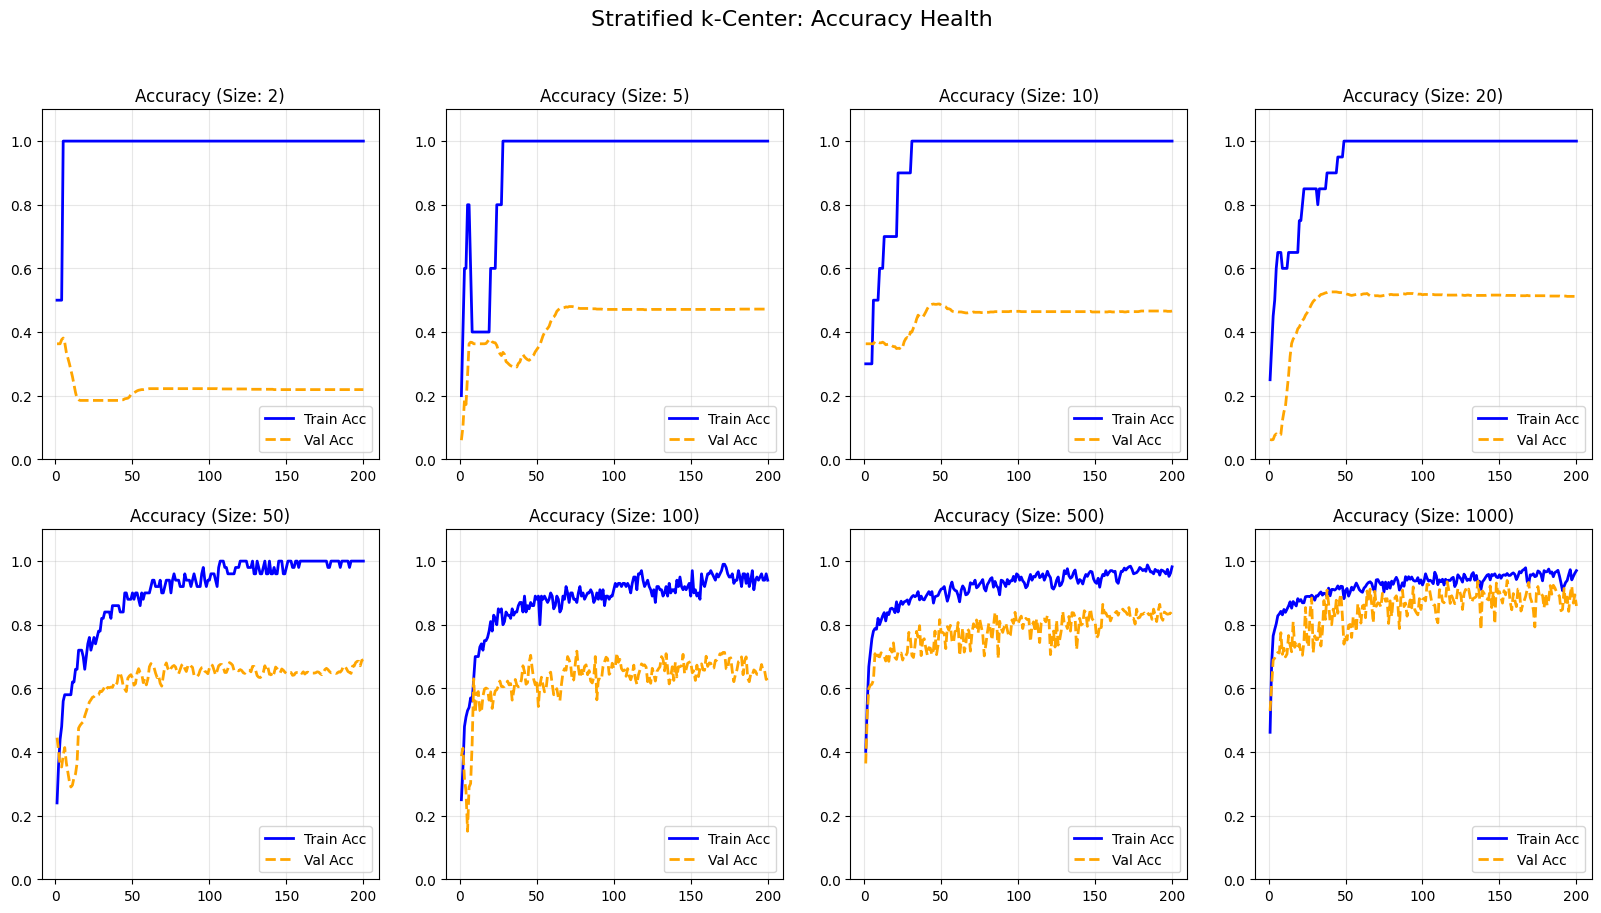

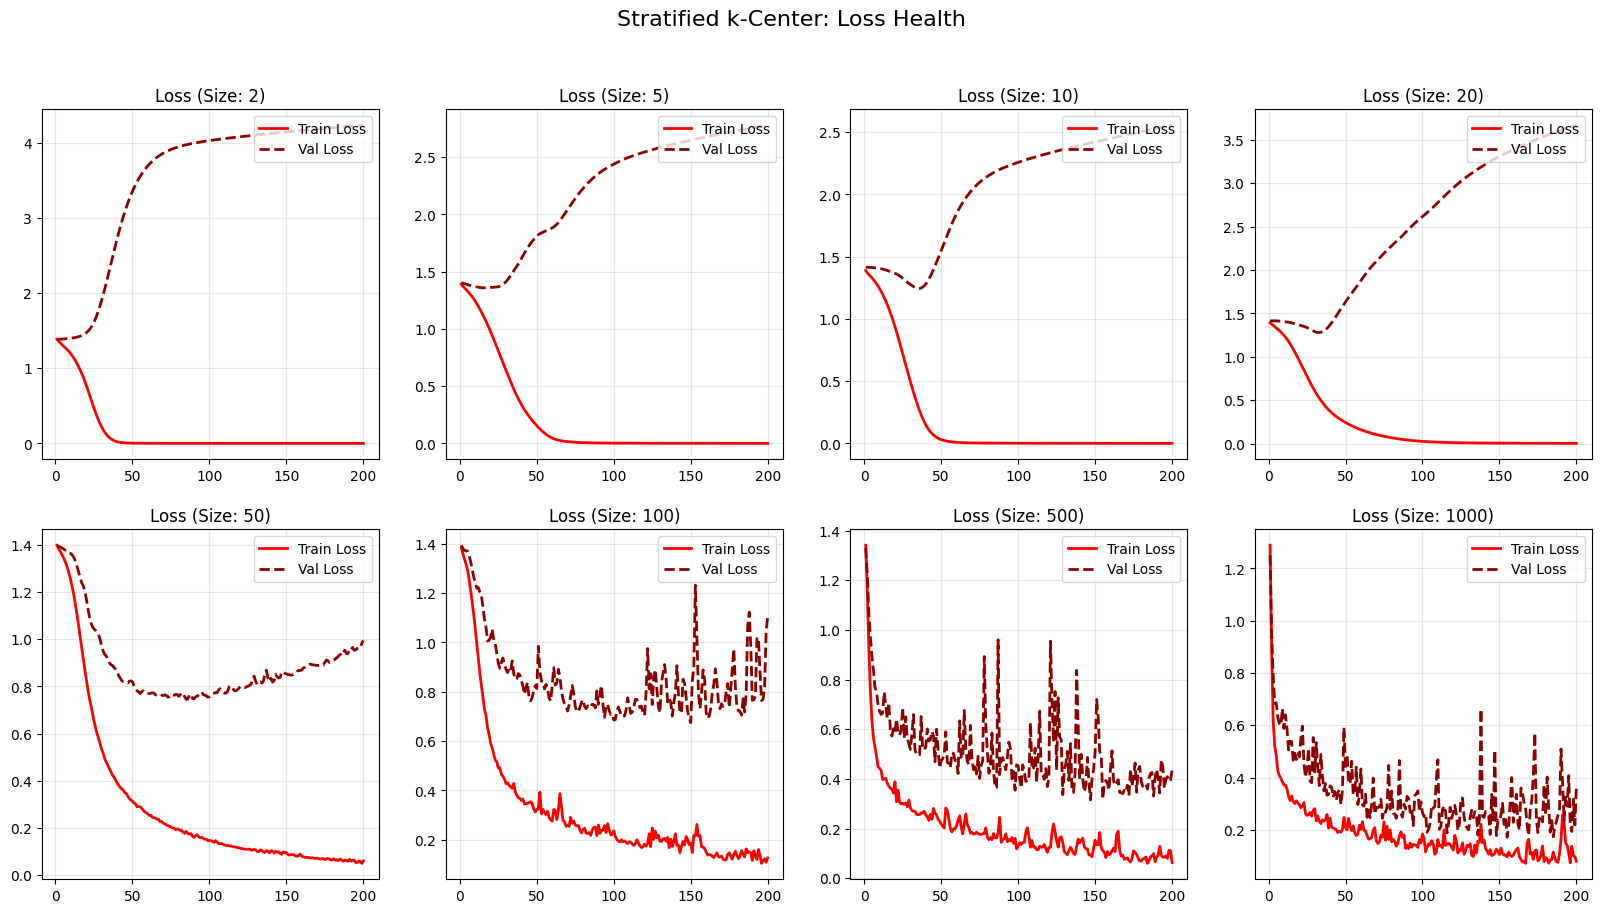

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

geometric_strategies = {
    "Stratified K-Means": k_means_coreset,
    "Stratified k-Center": k_center_greedy
}

# Using the second-to-last layer of the policy_net as the embedding source
extract_layer = best_expert.policy.mlp_extractor.policy_net[-2]

expert_embeddings = extract_expert_embeddings(pool_states, best_expert, extract_layer, device)
coreset_history = {}

for name, func in geometric_strategies.items():
    # 1. Build Datasets
    datasets = build_geometric_datasets(func, expert_embeddings, pool_states, pool_actions, FEW_SHOT_SIZES)
    # 2. Evaluate
    coreset_history[name] = evaluate_strategy(name, datasets, val_loader_fixed, FEW_SHOT_SIZES, device)

#### GradMatch and the Non-Adaptive BC Variant

**GradMatch** (Killamsetty et. al, ICML 2021) is a data selection strategy that aims to find a small subset (a coreset) of data whose weighted gradient closely matches the gradient of the entire dataset. By ensuring the gradient direction of the subset is similar to the full population, the model can theoretically achieve similar training dynamics with significantly fewer samples.

##### Standard GradMatch vs. Our Variant:
*   **Standard GradMatch**: Typically requires a "warm-start" (training on the full dataset for $R$ epochs) to get the model to a state where its gradients are meaningful, followed by adaptive subset selection during training.
*   **Our Non-Adaptive Variant**: Since our goal is extreme efficiency (Few-Shot), we want to avoid any warm-up on the full dataset. We achieve this by leveraging the **Expert Model** as a proxy. Instead of using the evolving gradients of the model being trained, we calculate the gradients relative to the expert's fixed knowledge. This allows us to select a high-quality coreset **before training ever begins**.

##### How it Works:
1.  **Proxy Gradients**: We pass the data through the expert to calculate the gradients for the final layer.
2.  **Selection**: We use a greedy matching algorithm to find samples whose expert-based gradients best represent the average gradient of the entire expert-collected pool.
3.  **One-Shot Selection**: Unlike standard GradMatch which re-selects data periodically, we select our budget once and train our BC model exclusively on that fixed coreset.

In [ ]:
def precompute_proxy_gradients(states, actions, proxy_model, device="cpu", batch_size=256):
    """
    Computes gradients for the entire dataset instantly using Analytical Gradients.
    """
    proxy_model.eval()

    X = torch.FloatTensor(states).to(device)
    y = torch.LongTensor(actions).to(device)
    all_grads = []

    # Get the number of classes from the final layer
    num_classes = proxy_model.net[-1].out_features

    # Hook to grab the input to the final layer (the embeddings)
    embeddings = []
    def hook(module, input, output):
        embeddings.append(input[0].detach())

    handle = proxy_model.net[-1].register_forward_hook(hook)

    for i in range(0, len(X), batch_size):
        embeddings.clear()

        # Completely disable autograd to save memory and time
        with torch.no_grad():
            logits = proxy_model(X[i:i+batch_size])

        emb = embeddings[0] # Shape: [batch_size, emb_dim]

        # Calculate the error: (Softmax Probs - OneHot Labels)
        probs = torch.nn.functional.softmax(logits, dim=1)
        labels_one_hot = torch.nn.functional.one_hot(y[i:i+batch_size], num_classes=num_classes)
        error = probs - labels_one_hot # Shape: [batch_size, num_classes]

        # The gradient of a Linear layer's weights is outer product: (error x embedding)
        # We reshape them to multiply efficiently across the batch
        grad_weight = error.unsqueeze(2) * emb.unsqueeze(1) # [batch, num_classes, emb_dim]

        # The gradient of a Linear layer's bias is exactly the error
        grad_bias = error # [batch, num_classes]

        # Flatten the weight gradients per sample to match autograd.grad formatting
        flat_grad_weight = grad_weight.view(grad_weight.size(0), -1)

        # Concatenate weights and bias gradients into one flat vector per sample
        flat_grad = torch.cat([flat_grad_weight, grad_bias], dim=1)

        all_grads.append(flat_grad.cpu().numpy())

    handle.remove()
    return np.concatenate(all_grads, axis=0)

def get_proxy_gradmatch_indices(precomputed_grads, budget):
    """
    Greedy L2 selection
    """
    target_grad = precomputed_grads.mean(axis=0)
    selected_indices = []
    current_grad_sum = np.zeros_like(target_grad)
    N = len(precomputed_grads)

    for step in range(1, budget + 1):
        available_mask = np.ones(N, dtype=bool)
        available_mask[selected_indices] = False
        available_indices = np.where(available_mask)[0]

        if len(available_indices) == 0: break

        candidate_sums = current_grad_sum + precomputed_grads[available_indices]
        candidate_means = candidate_sums / step
        distances = np.linalg.norm(candidate_means - target_grad, axis=1)

        min_dist_idx = np.argmin(distances)
        best_idx = available_indices[min_dist_idx]

        selected_indices.append(best_idx)
        current_grad_sum += precomputed_grads[best_idx]

    return selected_indices

def get_master_stratified_ordering(states, actions, precomputed_grads, max_budget):
    """
    Creates one ordered list of indices up to the maximum budget.
    """
    ordered_indices = []
    num_classes = len(np.unique(actions))
    samples_per_class = max(1, max_budget // num_classes)

    for action_val in range(num_classes):
        class_mask = np.where(actions == action_val)[0]
        if len(class_mask) == 0: continue

        class_grads = precomputed_grads[class_mask]
        class_budget = min(samples_per_class, len(class_mask))

        # Get local indices within the class
        local_indices = get_proxy_gradmatch_indices(class_grads, class_budget)

        # Map local indices back to global dataset indices
        global_indices = class_mask[local_indices]
        ordered_indices.append(global_indices)

    # Interleave the classes so the final list remains balanced when sliced
    interleaved_master_list = []
    max_length = max(len(lst) for lst in ordered_indices)

    for i in range(max_length):
        for class_list in ordered_indices:
            if i < len(class_list):
                interleaved_master_list.append(class_list[i])

    return np.array(interleaved_master_list)


 Evaluating Strategy: Proxy GradMatch
--- Training Budget Size: 2 ---
  Saved: proxy_gradmatch_model_2.pt
--- Training Budget Size: 5 ---
  Saved: proxy_gradmatch_model_5.pt
--- Training Budget Size: 10 ---
  Saved: proxy_gradmatch_model_10.pt
--- Training Budget Size: 20 ---
  Saved: proxy_gradmatch_model_20.pt
--- Training Budget Size: 50 ---
  Saved: proxy_gradmatch_model_50.pt
--- Training Budget Size: 100 ---
  Saved: proxy_gradmatch_model_100.pt
--- Training Budget Size: 500 ---
  Saved: proxy_gradmatch_model_500.pt
--- Training Budget Size: 1000 ---
  Saved: proxy_gradmatch_model_1000.pt

Generating training health plots for Proxy GradMatch...


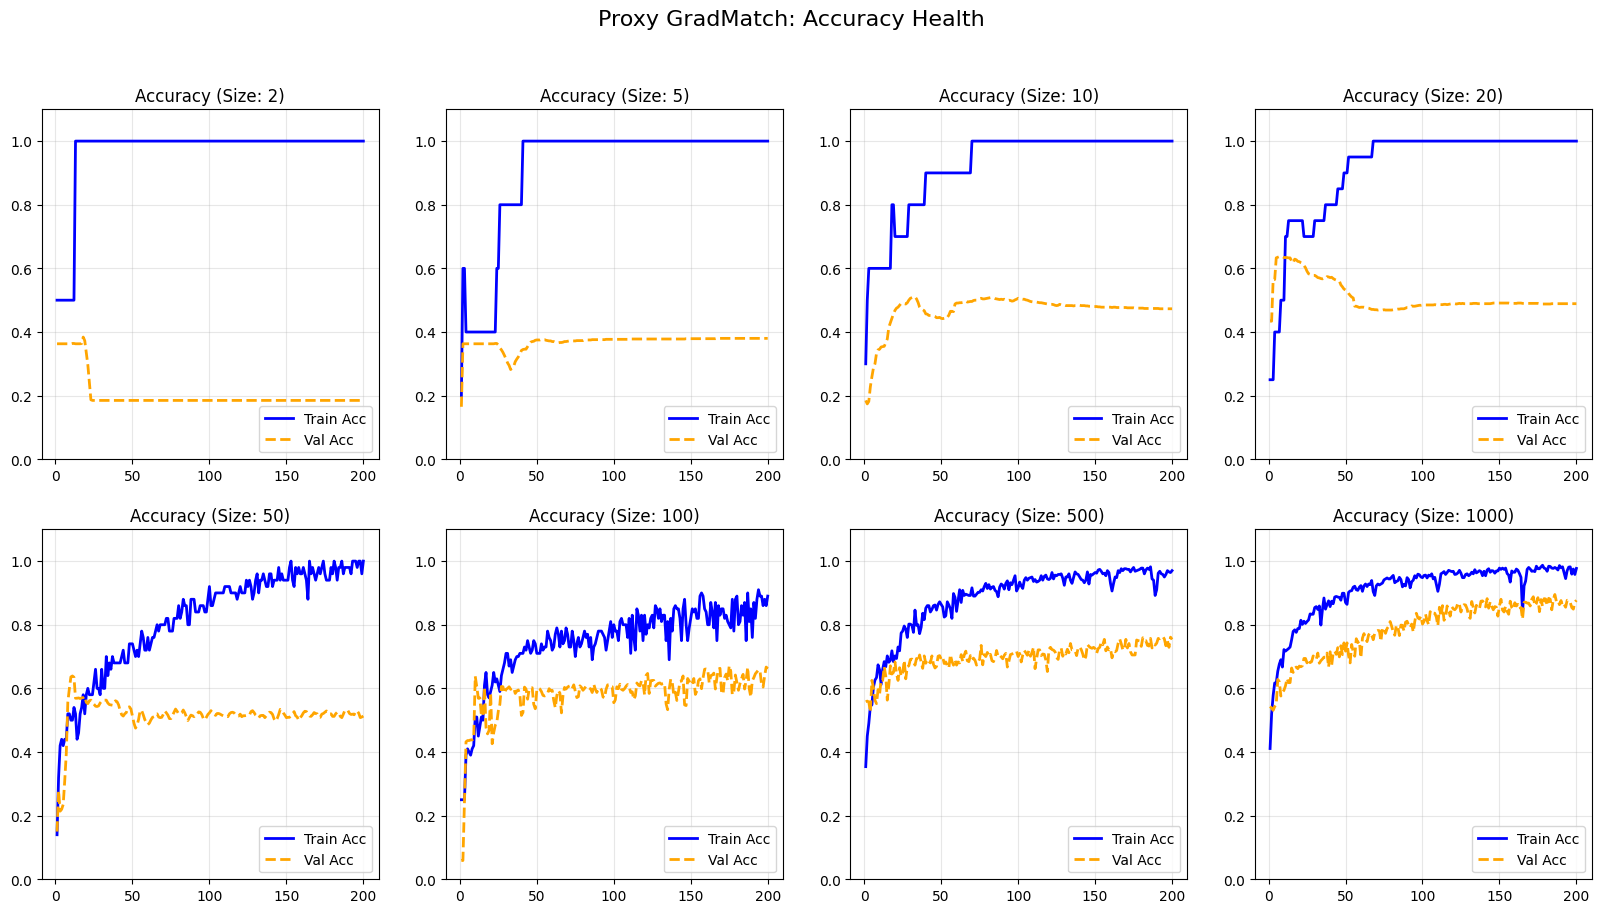

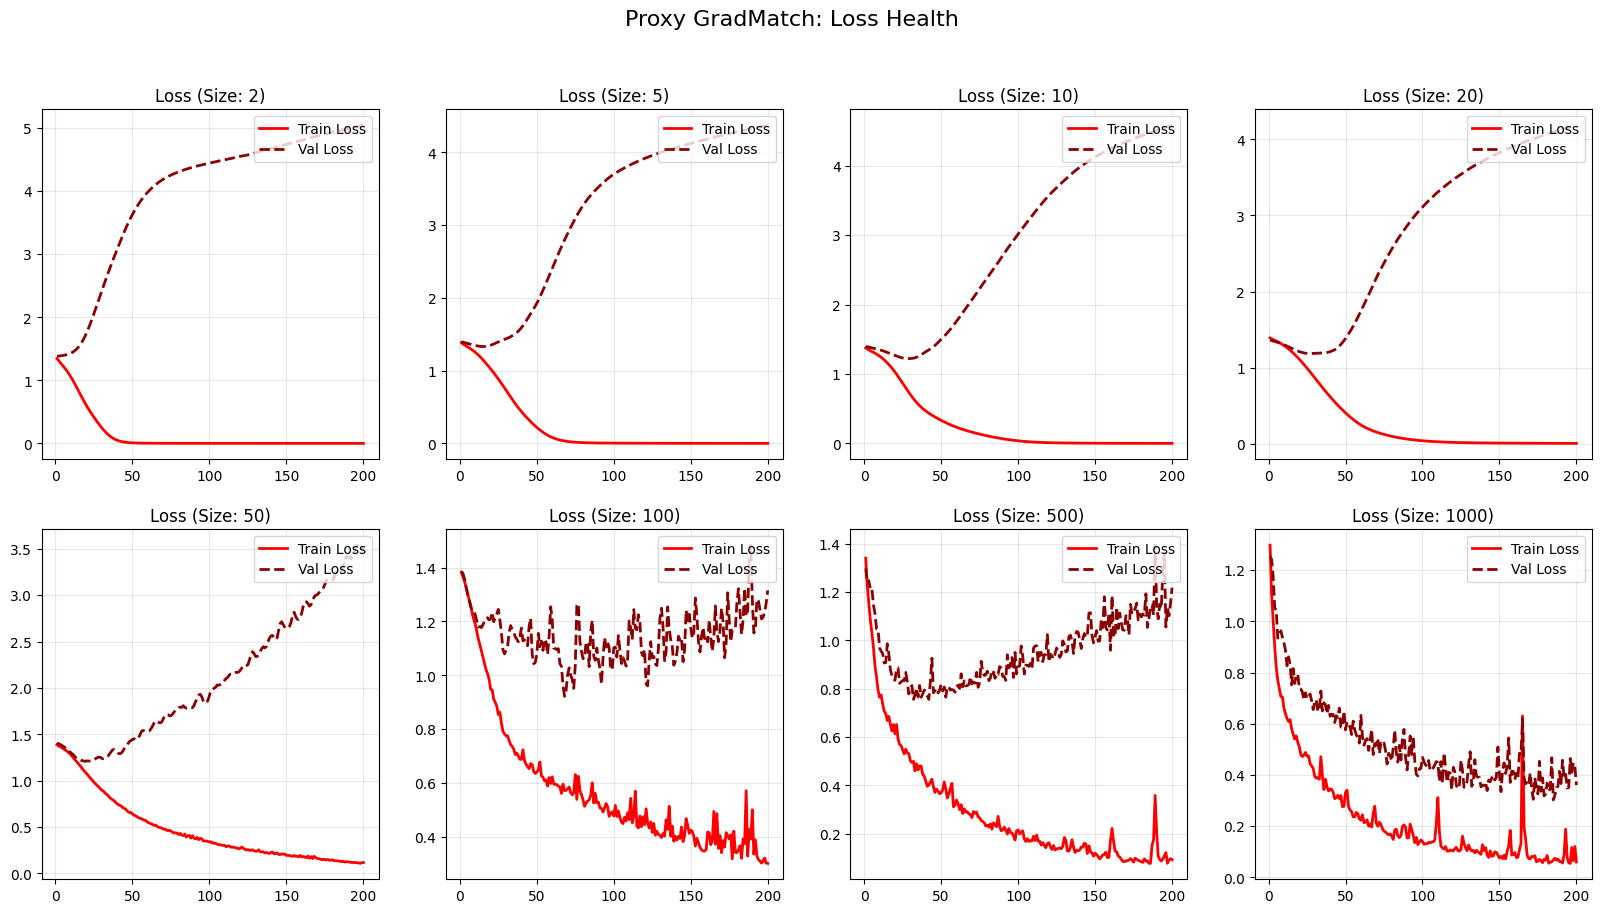

In [ ]:
# 1. Precompute Gradients once using the pretrained Imitation Model
# We use the 'imitation_model' which has the correct architecture for our BC task
# Ensure the model is on the same device as the data
imitation_model.to(device)
proxy_grads = precompute_proxy_gradients(pool_states, pool_actions, imitation_model, device=device)

# 2. Generate the Master Stratified Ordering
# This ensures that as we increase the budget, we keep the same core samples + new ones
master_indices = get_master_stratified_ordering(pool_states, pool_actions, proxy_grads, max(FEW_SHOT_SIZES))

# 3. Build Datasets (Slicing the master indices)
gradmatch_datasets = {}
for size in FEW_SHOT_SIZES:
    subset_indices = master_indices[:size]
    gradmatch_datasets[size] = {
        "states": pool_states[subset_indices],
        "actions": pool_actions[subset_indices]
    }

# 4. Evaluate
gradmatch_history = evaluate_strategy("Proxy GradMatch", gradmatch_datasets, val_loader_fixed, FEW_SHOT_SIZES, device)

#### Comparison

In [ ]:
def get_strategy_rewards(strategy_name, few_shot_sizes, device='cpu'):
    """Runs rollouts for all models across 5 seeds and returns averaged mean rewards."""
    final_strategy_means = []
    safe_name = strategy_name.replace(" ", "_").lower()
    eval_seeds = [42, 123, 7, 99, 1]

    for size in few_shot_sizes:
        model_path = f"./models/imitation/{safe_name}_model_{size}.pt"
        model = ImitationNet().to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        seed_rewards = []
        for run_seed in eval_seeds:
            # Run 50 episodes per seed for statistical stability
            results = run_imitaion_episodes(model, n_episodes=50, seed=run_seed)
            seed_rewards.append(results['mean_reward'])

        avg_reward = np.mean(seed_rewards)
        final_strategy_means.append(avg_reward)
        print(f"{strategy_name} (Size {size}): Aggregated Mean Reward = {avg_reward:.1f} (over 5 seeds)")

    return final_strategy_means

Random (Size 2): Aggregated Mean Reward = -567.2 (over 5 seeds)
Random (Size 5): Aggregated Mean Reward = -574.0 (over 5 seeds)
Random (Size 10): Aggregated Mean Reward = -618.7 (over 5 seeds)
Random (Size 20): Aggregated Mean Reward = -277.7 (over 5 seeds)
Random (Size 50): Aggregated Mean Reward = -384.0 (over 5 seeds)
Random (Size 100): Aggregated Mean Reward = -432.3 (over 5 seeds)
Random (Size 500): Aggregated Mean Reward = 198.3 (over 5 seeds)
Random (Size 1000): Aggregated Mean Reward = 210.4 (over 5 seeds)
Domain Knowledge (Size 2): Aggregated Mean Reward = -137.7 (over 5 seeds)
Domain Knowledge (Size 5): Aggregated Mean Reward = -125.0 (over 5 seeds)
Domain Knowledge (Size 10): Aggregated Mean Reward = -160.7 (over 5 seeds)
Domain Knowledge (Size 20): Aggregated Mean Reward = -240.1 (over 5 seeds)
Domain Knowledge (Size 50): Aggregated Mean Reward = 142.9 (over 5 seeds)
Domain Knowledge (Size 100): Aggregated Mean Reward = 183.0 (over 5 seeds)
Domain Knowledge (Size 500): Aggr

  result = self._expression.parseString(s)

  return fn(self, *args, **kwargs)

  ParserElement.resetCache()



Proxy GradMatch (Size 1000): Aggregated Mean Reward = 208.4 (over 5 seeds)


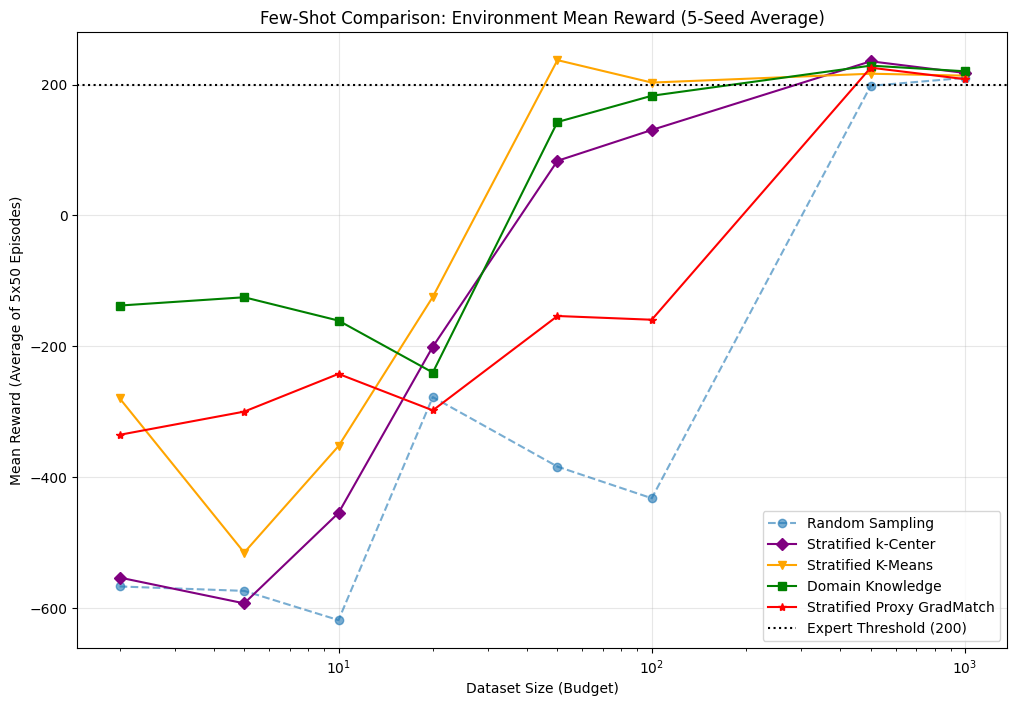

In [ ]:
# Collect averaged rewards for all strategies
print("Collecting environment rewards for all strategies (5-seed average)...")
random_env_rewards = get_strategy_rewards("Random", FEW_SHOT_SIZES, device)
domain_env_rewards = get_strategy_rewards("Domain Knowledge", FEW_SHOT_SIZES, device)
k_means_env_rewards = get_strategy_rewards("Stratified K-Means", FEW_SHOT_SIZES, device)
k_center_env_rewards = get_strategy_rewards("Stratified k-Center", FEW_SHOT_SIZES, device)
gradmatch_env_rewards = get_strategy_rewards("Proxy GradMatch", FEW_SHOT_SIZES, device)

# Plot comparison of Environment Rewards
plt.figure(figsize=(12, 8))
plt.plot(FEW_SHOT_SIZES, random_env_rewards, 'o--', label='Random Sampling', alpha=0.6)
plt.plot(FEW_SHOT_SIZES, k_center_env_rewards, 'D-', color='purple', label='Stratified k-Center')
plt.plot(FEW_SHOT_SIZES, k_means_env_rewards, 'v-', color='orange', label='Stratified K-Means')
plt.plot(FEW_SHOT_SIZES, domain_env_rewards, 's-', color='green', label='Domain Knowledge')
plt.plot(FEW_SHOT_SIZES, gradmatch_env_rewards, '*-', color='red', label='Stratified Proxy GradMatch')

plt.xscale('log')
plt.axhline(y=200, color='black', linestyle=':', label='Expert Threshold (200)')
plt.title('Few-Shot Comparison: Environment Mean Reward (5-Seed Average)')
plt.xlabel('Dataset Size (Budget)')
plt.ylabel('Mean Reward (Average of 5x50 Episodes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Load the winning model (Stratified K-Means, Size 50)
winning_model = ImitationNet()
winning_model.load_state_dict(torch.load('./models/imitation/stratified_k-means_model_50.pt', map_location='cpu'))
winning_model.eval()

# 2. Setup environment for rendering
eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")
frames = []
obs, info = eval_env.reset(seed=42)
done = False

# 3. Rollout one episode
while not done:
    frames.append(eval_env.render())
    # Predict action using the winning model
    action, _ = winning_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

eval_env.close()

# 4. Generate and display the video
video_filename = "LunarLander_stratified_kmeans_50.mp4"
create_video(frames, video_filename=video_filename, fps=30)

Moviepy - Building video LunarLander_stratified_kmeans_50.mp4.
Moviepy - Writing video LunarLander_stratified_kmeans_50.mp4



Moviepy - Done !
Moviepy - video ready LunarLander_stratified_kmeans_50.mp4


#### Summary of Selection Strategies
In this section, we compared three ways to pick training data for few-shot learning:
1. **Random Sampling**: The standard baseline.
2. **Stratified GradMatch**: Selecting samples that best represent the overall gradient direction.
3. **Domain Knowledge**: Ensuring spatial and action coverage across the LunarLander environment.